# Data Science Capstone, Adult Census Income: Final Model Comparison and Fairness Audit

Erik Herb · MSDS640 Data Science Capstone · Bryant University · UCI Adult Census Income (1994 U.S. Census)

## Abstract

This project predicts whether a person earns more than \$50K a year from census demographic, education, and job
information, framed as a lender that flags likely high earners. I train three models on the UCI Adult Census Income
data, a logistic regression baseline, XGBoost, and a multilayer perceptron, all inside one pipeline that scales the
numeric columns and applies SMOTE to training rows only. I compare them on a held-out test set and on five stratified
cross-validation folds, and I back every comparison with a statistical test and not just an eyeballed difference,
using paired t-tests and Wilcoxon signed-rank tests on the same folds, McNemar's exact test on the same test rows,
and paired bootstrap confidence intervals. H1 is that education drives the over-\$50K prediction more than hours
worked, and permutation importance on all three models supports it with intervals that exclude zero. H3 is that
XGBoost beats both the baseline and the MLP on PR-AUC and F1, and it is supported, with every paired test
significant. H2 is that XGBoost is the fairest across nativity, and it is refuted: XGBoost has the largest recall gap
of the three, and no difference between models is statistically distinguishable at this sample size. The
accuracy-first model is not the fairness-first model here, which is the most useful thing the project found.

## Introduction

The problem

- I predict whether a person earns more than \$50K a year from demographic, education, and job information, framed as
a lender or screening tool that flags likely high earners.
- That framing decides which errors matter. A missed high earner is lost business for the lender and a denied
opportunity for the applicant, so I care about recall on the positive class and about which features drive the
decision, not about raw accuracy.
- Accuracy is actively misleading here: a model that predicts nobody earns over \$50K is already right about 76
percent of the time while catching zero real high earners.

Why it matters

- The same structure shows up in lending, credit limits, insurance pricing, and marketing, so this is a template for
decisions that affect people's access to money.
- The lender benefits from catching more high earners. The applicant benefits from a model that does not quietly work
worse for the group they belong to, which is why the fairness audit sits next to the accuracy comparison instead of after it.

Background

- Adult Census Income is a standard benchmark for tabular binary classification and a standard dataset in the
fairness literature, since it carries sex, race, and native country alongside an income label.
- Gradient boosted trees are the usual strong performer on tabular data of this size, which is where my H3
expectation comes from. The fairness side is where I had no settled expectation, and that is what H2 tests.

## Research questions and hypotheses

RQ1: which drives the over-\$50K prediction more, education level or hours worked?

- H1: education level is the stronger driver.
- Testable because permutation importance measures how much each feature contributes to a trained model, and a
confidence interval on the difference either excludes zero or does not.

RQ2: which of the three models is fairest across nativity toward true high earners?

- H2: XGBoost has the smallest US-born versus foreign-born recall gap on real high earners.
- Testable because recall can be computed separately for each group, the gap is one number per model, and a paired
bootstrap gives an interval on the difference between two models' gaps.
- The foreign-born group is about 9 percent of the data, so this asks how each model behaves on a group it sees far
less of.

RQ3: which of the three models classifies best on held-out data?

- H3: XGBoost beats both the logistic regression baseline and the MLP on PR-AUC and F1.
- The reasoning is specific, not a guess that the fancier model wins. My EDA found real non-linear structure:
the over-\$50K rate rises through the working years and falls at the oldest ages, having any capital gain flips the
rate sharply, and education and marital status matter together instead of separately. Boosted trees capture curves,
thresholds, and interactions by splitting, while logistic regression only gets them if I add them by hand.
- Dataset size points the same way. About 32,500 rows is small for a neural network, which usually needs far more
data to learn those interactions from scratch, and it is comfortably enough for a boosted tree ensemble. So the data
is not large enough to favor the MLP and not linear enough to favor logistic regression.
- Testable because PR-AUC and F1 can be computed on the same held-out rows and the same folds for all three models,
and paired tests say whether the differences exceed fold-to-fold noise.

## Setup

- The libraries, the navy and gold plot colors I use across the project, and one fixed seed everywhere.

In [1]:
# libraries, the navy and gold plot colors I use across the project, and a fixed seed
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import sqlite3, time
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn import metrics

NAVY = "#1f3a5f"
GOLD = "#c9a227"
RUST = "#b0654a"
GREY = "#7a8ba3"
SEED = 42
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110
%matplotlib inline

In [2]:
# the small performance helper from class, so every model prints the same way
def measure_performance(X, y, clf, show_accuracy=True, show_classification_report=True, show_confusion_matrix=True):
    y_pred = clf.predict(X)
    if show_accuracy:
        print("Accuracy:{0:.3f}".format(metrics.accuracy_score(y, y_pred)), "\n")
    if show_classification_report:
        print("Classification report")
        print(metrics.classification_report(y, y_pred), "\n")
    if show_confusion_matrix:
        print("Confusion matrix")
        print(metrics.confusion_matrix(y, y_pred), "\n")

In [3]:
# one scoring helper so every table below reports the same six metrics
def score_row(name, model, X_, y_):
    p = model.predict(X_)
    prob = model.predict_proba(X_)[:, 1]
    return {"model": name,
            "accuracy": metrics.accuracy_score(y_, p),
            "precision": metrics.precision_score(y_, p),
            "recall": metrics.recall_score(y_, p),
            "f1": metrics.f1_score(y_, p),
            "PR-AUC": metrics.average_precision_score(y_, prob),
            "ROC-AUC": metrics.roc_auc_score(y_, prob)}

## Data

- Source: the Adult Census Income dataset, extracted by Barry Becker from the 1994 U.S. Census Bureau database and
hosted by the UCI Machine Learning Repository.
- Collection: a Census Bureau population survey, filtered to records with age over 16 and a positive reported income.
- Size: 32,561 rows and 15 raw columns, one row per person. After cleaning it is 32,537 rows and 13 columns, plus the
engineered ones below.
- Time range: a single snapshot of the 1994 census year. There is no time dimension, so no temporal split applies.
- License and access: public, released for research use under the UCI repository terms, no access restrictions, and
anonymized at source.
- Target: income over \$50K or \$50K and under, imbalanced at about 24 percent high earners.
- As in every earlier milestone, the data is loaded into SQLite and pulled back out before any analysis, so the
database is the single source of truth.

In [4]:
# read the raw csv into the database, then pull it back out into the dataframe I model on
raw = pd.read_csv("adult.csv", na_values="?", skipinitialspace=True)
conn = sqlite3.connect("adult.db")
raw.to_sql("adult", conn, if_exists="replace", index=False)
df = pd.read_sql("SELECT * FROM adult", conn)
conn.close()
print("Pulled", df.shape[0], "rows and", df.shape[1], "columns from the database")

Pulled 32561 rows and 15 columns from the database


## Data preprocessing

- Everything here is the preprocessing I justified in the EDA milestone, run here instead of re-argued.

Missing values

- Only workclass (5.64 percent), occupation (5.66 percent), and native country (1.79 percent) are missing anything,
and all three are categorical.
- I fill each with an explicit Unknown category. Dropping those rows would throw away roughly 2,400 people, and the
missingness is not random, so dropping could bias the analysis. An Unknown bucket keeps the rows and lets the model
treat missingness as its own signal.

Duplicates and dropped columns

- I drop the 24 exact duplicates while the sampling weight is still in the table, because that weight is close to
unique per row and dropping it first would make genuinely different people look identical.
- I then drop the sampling weight, which is a census weight, not a fact about the person, and the text
education column, which repeats the numeric one.

Outliers

- I keep every flagged outlier, because I measured what dropping them would cost. The IQR rule flags 39.7 percent of
the data and 47.2 percent of all high earners, and flagged rows are signal, not noise, since rows flagged
on capital gain are 61.8 percent high earners against 20.7 percent for everyone else.
- Dropping would also skew the audit, since foreign-born people are flagged at 45.3 percent against 39.2 percent for
US-born, so I would measure a nativity gap on a sample already skewed by nativity.

Encoding, scaling, and class imbalance

- One-hot encode the eight categorical columns with the first level dropped, giving 52 model columns.
- Standardize the five continuous columns and pass the dummies and flags through untouched, since scaling a 0/1
column does nothing. Scaling matters for logistic regression and the MLP and is harmless for XGBoost, which splits on
order. The scaler is fit inside the pipeline, so it only ever sees training rows.
- The target is about 3.2 to 1. I oversample the minority class with SMOTE on training rows instead of undersampling, because undersampling would throw away most of the real under-\$50K rows while oversampling keeps
every real row.

In [5]:
# fill missing categoricals with Unknown, drop duplicates before dropping fnlwgt, then drop fnlwgt and education
for col in ["workclass", "occupation", "native.country"]:
    df[col] = df[col].fillna("Unknown")
df = df.drop_duplicates()
df = df.drop(columns=["fnlwgt", "education"])
print("Shape after cleaning:", df.shape, " missing values left:", int(df.isna().sum().sum()))

Shape after cleaning: (32537, 13)  missing values left: 0


In [6]:
# clean the target label, switch the dotted column names to underscores, and add the 1/0 target
df["income"] = df["income"].str.strip().str.replace(".", "", regex=False)
df.columns = df.columns.str.replace(".", "_", regex=False)
df["high_income"] = (df["income"] == ">50K").astype(int)
print(df["income"].unique(), "-> positive rate", round(df["high_income"].mean(), 3))

<StringArray>
['<=50K', '>50K']
Length: 2, dtype: str -> positive rate 0.241


## Feature engineering

- I add four features, each tied to a hypothesis or to a modeling problem, not added just to have more columns.

- native_region groups native country into US, non-US, and Unknown. The raw column is 90 percent United States across
42 categories, so encoding it directly would produce dozens of nearly empty columns. Grouping gives the split my
fairness audit needs for H2 while keeping missing-country people separate.
- has_capital_gain and has_capital_loss flag whether a person has any capital gain or loss. Those columns are almost
always zero with a few very large values, so a flag captures the wealth signal without the model over-reacting to the
dollar amount, and it gives the linear model a threshold effect it could not otherwise express.
- hours_group bins hours per week. My EDA showed the effect of hours rises and then flattens above full time, so
binning lets the linear model express that shape and gives hours a fair shot in the H1 comparison.

Dimensionality reduction and feature selection

- I do neither. PCA on the numeric features spread variance evenly across components, there are only seven numeric
features with no strong multicollinearity, and H1 depends on knowing which original feature matters, which PCA
components would destroy.
- What I do check below is a before and after comparison of the engineered feature set, so the claim that these four
earn their place is measured and not just asserted.

In [7]:
# rebuild the engineered features from the EDA milestone
df["native_region"] = df["native_country"].apply(
    lambda c: "US" if c == "United-States" else ("Unknown" if c == "Unknown" else "non-US"))
df["has_capital_gain"] = (df["capital_gain"] > 0).astype(int)
df["has_capital_loss"] = (df["capital_loss"] > 0).astype(int)
df["hours_group"] = pd.cut(df["hours_per_week"], bins=[0, 20, 35, 40, 45, 60, 100],
                           labels=["<=20", "21-35", "36-40", "41-45", "46-60", "60+"])
print("Engineered columns added:", ["native_region", "has_capital_gain", "has_capital_loss", "hours_group"])

Engineered columns added: ['native_region', 'has_capital_gain', 'has_capital_loss', 'hours_group']


In [8]:
# one hot encode the categoricals and join the numeric columns into the model matrix X, with y as the target
cat_cols = ["workclass", "marital_status", "occupation", "relationship",
            "race", "sex", "native_region", "hours_group"]
num_cols = ["age", "education_num", "capital_gain", "capital_loss", "hours_per_week",
            "has_capital_gain", "has_capital_loss"]
X = pd.get_dummies(df[cat_cols], drop_first=True).astype(int)
X = pd.concat([df[num_cols], X], axis=1)
y = df["high_income"]
print("Model matrix X:", X.shape, " target y:", y.shape)

Model matrix X: (32537, 52)  target y: (32537,)


## EDA findings that matter for the hypotheses

- I am not repeating the whole EDA milestone here. These are the four findings the rest of the report depends on, so I
carry them forward and leave the rest behind.

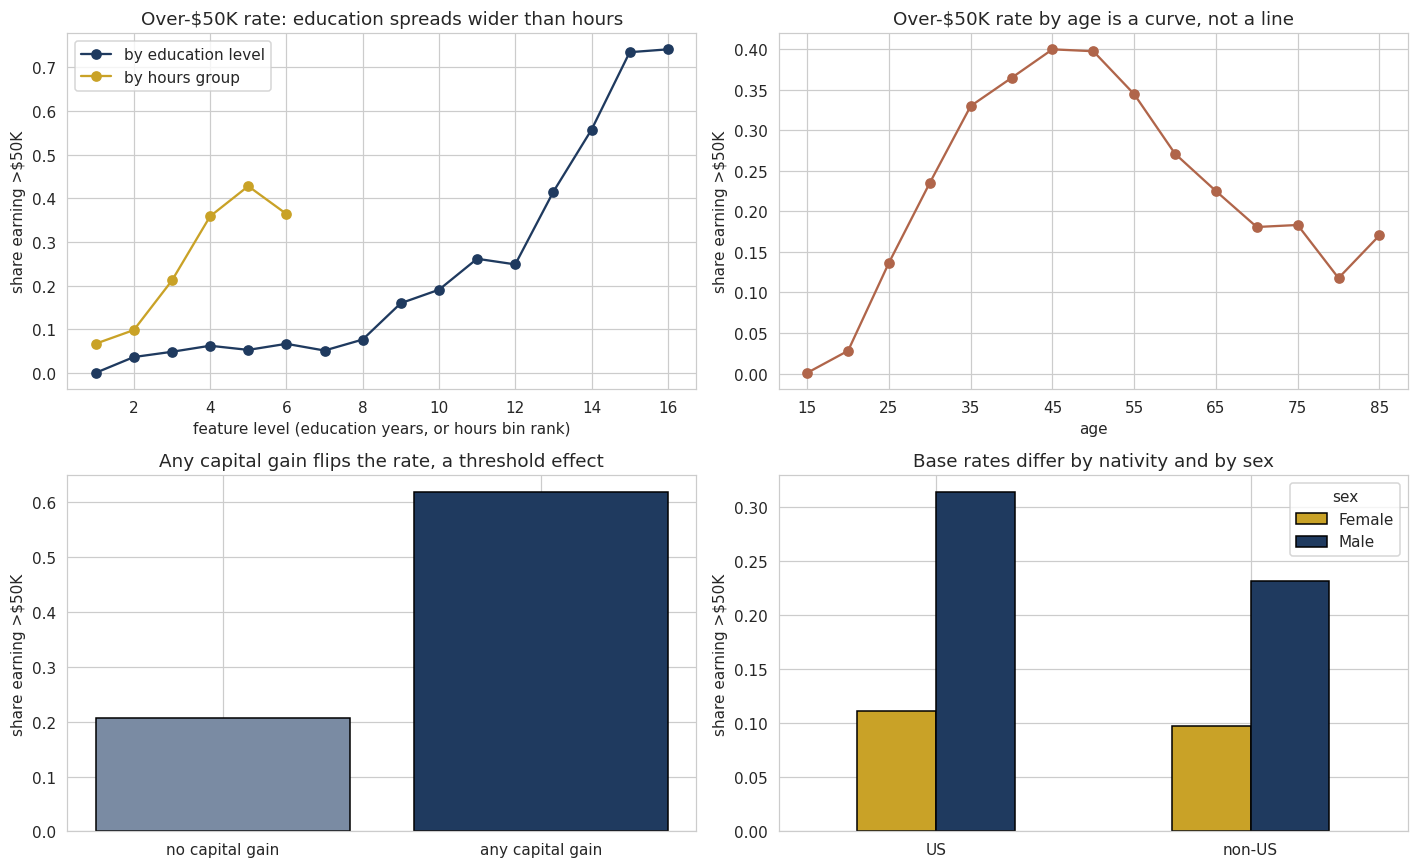

                       mean   size
native_region sex                 
US            Female  0.111   9676
              Male    0.313  19477
Unknown       Female  0.104    163
              Male    0.308    419
non-US        Female  0.098    923
              Male    0.231   1879


In [9]:
# the four EDA findings the hypotheses rest on, in one figure
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
edu_rate = df.groupby("education_num")["high_income"].mean()
hrs_rate = df.groupby("hours_group", observed=True)["high_income"].mean()
axes[0, 0].plot(edu_rate.index, edu_rate.values, "o-", color=NAVY, label="by education level")
axes[0, 0].plot(range(1, len(hrs_rate) + 1), hrs_rate.values, "o-", color=GOLD, label="by hours group")
axes[0, 0].set_title("Over-$50K rate: education spreads wider than hours")
axes[0, 0].set_xlabel("feature level (education years, or hours bin rank)")
axes[0, 0].set_ylabel("share earning >$50K")
axes[0, 0].legend()
age_rate = df.groupby(pd.cut(df["age"], bins=range(15, 96, 5)), observed=True)["high_income"].mean()
axes[0, 1].plot(range(len(age_rate)), age_rate.values, "o-", color=RUST)
axes[0, 1].set_xticks(range(0, len(age_rate), 2))
axes[0, 1].set_xticklabels([str(i.left) for i in age_rate.index[::2]])
axes[0, 1].set_title("Over-$50K rate by age is a curve, not a line")
axes[0, 1].set_xlabel("age")
axes[0, 1].set_ylabel("share earning >$50K")
cap_rate = df.groupby("has_capital_gain")["high_income"].mean()
axes[1, 0].bar(["no capital gain", "any capital gain"], cap_rate.values, color=[GREY, NAVY], edgecolor="black")
axes[1, 0].set_title("Any capital gain flips the rate, a threshold effect")
axes[1, 0].set_ylabel("share earning >$50K")
grp = df[df["native_region"] != "Unknown"].groupby(["native_region", "sex"])["high_income"].mean().unstack()
grp.plot(kind="bar", ax=axes[1, 1], color=[GOLD, NAVY], edgecolor="black")
axes[1, 1].set_title("Base rates differ by nativity and by sex")
axes[1, 1].set_ylabel("share earning >$50K")
axes[1, 1].set_xlabel("")
axes[1, 1].tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()
print(df.groupby(["native_region", "sex"])["high_income"].agg(["mean", "size"]).round(3).to_string())

- Top left is the H1 hint. Education spreads the over-\$50K rate by about 0.74 from its lowest to highest level while
hours spreads it by about 0.36, and education climbs steadily while hours flattens. This is one feature at a time, so it is a hint, not a test.
- Top right and bottom left are the H3 reasoning. The rate by age is a curve that a linear model cannot express
without an age-squared term, and having any capital gain flips the rate sharply instead of gradually. Curves and
thresholds are what tree splits capture.
- Bottom right sets up H2. US-born people earn over \$50K at about 24.6 percent against 18.7 percent for
foreign-born, and men are higher inside both groups. Those base-rate gaps are real and are what the models learn
from, so a recall gap later cannot be blamed entirely on the model.

## Train, validation, and test split

- A three-way stratified split, 60 percent train, 20 percent validation, 20 percent test, stratified on the target so
the 0.241 positive rate holds in all three.
- Training fits the models, validation makes every decision including tuning and the group thresholds, and the test
set stays untouched until the final evaluation so the last numbers are honest.

How I confirm no leakage occurred

- Scaling and SMOTE live inside the pipeline, so they are fit on training rows only and then applied to held-out rows
without being refit.
- Because they live in the pipeline, cross-validation refits both inside each fold, so the scaler never sees the
validation fold and SMOTE never generates a synthetic row from one.
- SMOTE runs after the split, never before, so no synthetic row derived from a training person can appear in
validation or test.
- The test set is used in exactly one place, the final evaluation.

In [10]:
# hold out a stratified 20 percent test set, then split the rest into train and validation (a 60/20/20 split)
from sklearn.model_selection import train_test_split
X_temp, Xte, y_temp, yte = train_test_split(X, y, test_size=0.20, stratify=y, random_state=SEED)
Xtr, Xval, ytr, yval = train_test_split(X_temp, y_temp, test_size=0.25, stratify=y_temp, random_state=SEED)
print("Train:", Xtr.shape[0], " Validation:", Xval.shape[0], " Test:", Xte.shape[0])
print("Positive rate  train:", round(ytr.mean(), 3), " val:", round(yval.mean(), 3), " test:", round(yte.mean(), 3))

Train: 19521  Validation: 6508  Test: 6508
Positive rate  train: 0.241  val: 0.241  test: 0.241


In [11]:
# build a fresh scaler each time, so every model gets its own and one model's fit cannot change another's
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
scale_cols = ["age", "education_num", "capital_gain", "capital_loss", "hours_per_week"]

def make_pre(cols=None):
    return ColumnTransformer([("scale", StandardScaler(), cols if cols else scale_cols)], remainder="passthrough")

print("Scaling", len(scale_cols), "numeric columns, passing the remaining", X.shape[1] - len(scale_cols), "through unchanged")

Scaling 5 numeric columns, passing the remaining 47 through unchanged


In [12]:
# keep the group labels for every row so the fairness audit can slice any split by nativity and sex
grp_nat = df.loc[X.index, "native_region"]
grp_sex = df.loc[X.index, "sex"]
print(grp_nat.value_counts().to_string())
print()
print(grp_sex.value_counts().to_string())

native_region
US         29153
non-US      2802
Unknown      582

sex
Male      21775
Female    10762


## Did the engineered features earn their place

- Before building the real models I check the one optional item from the guidelines, a before and after comparison of
the feature set, because it is cheap and it turns an assumption into a measurement.
- I fit the same default logistic regression twice on the same split, once on the raw columns only and once with the
four engineered features added, and compare on the validation set.

In [13]:
# same default model on the raw feature set vs the engineered one, to see whether the four added features pay off
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
raw_cat = ["workclass", "marital_status", "occupation", "relationship", "race", "sex", "native_country"]
raw_num = ["age", "education_num", "capital_gain", "capital_loss", "hours_per_week"]
X_raw = pd.concat([df[raw_num], pd.get_dummies(df[raw_cat], drop_first=True).astype(int)], axis=1)
fs_rows = []
for label, Xset, cols in [("raw features only", X_raw, raw_num), ("with engineered features", X, scale_cols)]:
    a, b = Xset.loc[Xtr.index], Xset.loc[Xval.index]
    m = ImbPipeline([("prep", make_pre(cols)), ("smote", SMOTE(random_state=SEED)),
                     ("clf", LogisticRegression(max_iter=1000, random_state=SEED))]).fit(a, ytr)
    r = score_row(label, m, b, yval)
    r["n_columns"] = Xset.shape[1]
    fs_rows.append(r)
feature_set_table = pd.DataFrame(fs_rows).set_index("model").round(3)
print("Same default logistic regression, two feature sets, scored on the validation set\n")
print(feature_set_table.to_string())

Same default logistic regression, two feature sets, scored on the validation set

                          accuracy  precision  recall     f1  PR-AUC  ROC-AUC  n_columns
model                                                                                   
raw features only            0.811      0.573   0.849  0.685   0.759    0.905         84
with engineered features     0.815      0.580   0.850  0.689   0.773    0.909         52


## Methodology: the experimental pipeline

The pipeline, start to finish

- Load the raw CSV into SQLite once, then pull every row back out with a SQL query.
- Clean: fill the three gapped categorical columns with Unknown, drop the 24 duplicates before dropping the sampling
weight, drop the sampling weight and the text education column, build the 0/1 target.
- Engineer four features, then one-hot encode, giving 52 columns.
- Split 60/20/20, stratified, fixed seed.
- Fit inside one pipeline: standardize the continuous columns, apply SMOTE to training rows, fit the classifier.
- Tune: fit each setting on training, score PR-AUC on validation, keep the best.
- Cross-validate: 5-fold stratified on the training rows, identical folds across all three models.
- Evaluate on the untouched test set, then run paired tests and bootstrap intervals on the differences.
- Audit: split test rows by nativity and sex, compute recall inside each group, test whether the gaps differ.

Cross-validation strategy and seeds

- Five folds keep enough minority-class rows per fold for a steady PR-AUC, and stratifying holds the 24 percent
positive rate in every fold.
- I generate the fold indices once and reuse them for all three models. That is what leaves the fold scores paired,
and pairing is the only thing that gives a t-test power on five observations.
- One seed, 42, on the split, the folds, SMOTE, and all three models.

Software

- Python with numpy, pandas, scikit-learn, imbalanced-learn, xgboost, scipy, matplotlib, and seaborn. Versions are
printed at the end.

## The models, and how each one makes a prediction

The naive baseline

- A majority-class predictor that labels everyone as under \$50K. It scores about 76 percent accuracy while catching
zero real high earners, so any model that cannot beat it on recall and PR-AUC has learned nothing.

Logistic regression, the interpretable baseline

- It takes a weighted sum of the features, passes it through the sigmoid to get a probability, and applies a 0.5
threshold.

$$z = \beta_0 + \sum_{j=1}^{p} \beta_j x_j, \qquad \hat{p} = \sigma(z) = \frac{1}{1 + e^{-z}}$$

where $x_j$ is feature $j$ for a person, $\beta_j$ is its learned coefficient, $\beta_0$ is the intercept, $p$ is the
number of features, and $\hat{p}$ is the predicted probability of earning over \$50K.

- It is fit by minimizing log loss, which punishes confident wrong answers far more than uncertain ones:

$$L = -\frac{1}{n}\sum_{i=1}^{n}\Big[ y_i \log(\hat{p}_i) + (1 - y_i)\log(1 - \hat{p}_i) \Big] + \frac{1}{C}R(\beta)$$

where $n$ is the number of training rows, $y_i$ is the true label, $\hat{p}_i$ the predicted probability, $R(\beta)$
the regularization penalty, and $C$ the inverse regularization strength.

- The limit that matters: it is linear and additive, so it misses interactions and curves unless I engineer them.
That limit is what H3 tests.

XGBoost, the gradient boosted trees

- It builds shallow trees one at a time, each fit to the errors the ensemble has made so far, and the prediction is
the sum of every tree's output through the sigmoid:

$$\hat{y}_i = \sigma\Big(\sum_{k=1}^{K} \eta \, f_k(x_i)\Big)$$

where $f_k$ is the $k$-th tree, $f_k(x_i)$ is the value it assigns by dropping a person down its splits, $\eta$ is
the learning rate, and $K$ is the number of trees.

- Each tree is grown by choosing splits that most reduce a regularized objective, so it adds complexity only where
the gain is worth it:

$$\mathcal{L} = \sum_{i=1}^{n} \ell(y_i, \hat{y}_i) + \sum_{k=1}^{K}\Big(\gamma T_k + \tfrac{1}{2}\lambda \|w_k\|^2\Big)$$

where $\ell$ is the log loss above, $T_k$ is the leaf count of tree $k$, $w_k$ its leaf values, $\gamma$ the cost of a
leaf, and $\lambda$ the L2 penalty on leaf values.

- Because a split can fall at any value and later trees split inside regions earlier trees carved out, it captures
thresholds, curves, and interactions without being told they exist. That is the mechanism behind H3.

The multilayer perceptron

- It passes the features through hidden layers where each neuron takes a weighted sum and applies a non-linear
activation, and the output layer turns that into a probability:

$$h = \text{ReLU}(W_1 x + b_1), \qquad \hat{p} = \sigma(W_2 h + b_2)$$

where $x$ is one person's feature vector, $W_1$ and $b_1$ are the hidden layer's weights and biases, $h$ the hidden
representation, $\text{ReLU}(u) = \max(0, u)$, and $W_2$ and $b_2$ map that to the output.

- Stacking non-linear layers can represent interactions too, but it has to learn them with no structural head start,
which is why I expect it to need more rows than this dataset has.

## Evaluation methodology

The metrics, and why each is here

$$\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}, \qquad \text{Precision} = \frac{TP}{TP + FP}, \qquad \text{Recall} = \frac{TP}{TP + FN}$$

$$F_1 = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}$$

- Accuracy is the overall share correct. I report it but never lead with it, since the majority-class floor already
scores about 76 percent.
- Precision is the share of people I flag who really are high earners, which for the lender is wasted review effort.
- Recall is the share of real high earners I catch. For the lender that is lost business, and it is the metric the
whole fairness audit is built on, because a recall gap means the model finds one group's high earners and misses the
other's.
- F1 is the harmonic mean, so it stays low unless both are decent.
- PR-AUC is my lead metric. It focuses on the positive class, gets no credit for rejecting the easy majority, has a
no-skill floor at the 0.241 base rate instead of 0.5, and is threshold-free, so it compares ranking rather than
where a cutoff lands.
- ROC-AUC stays secondary because a large easy negative class props its curve up on imbalanced data.

The statistical methods, and why each fits

- Paired t-test on cross-validation fold scores. Every model saw the same five folds, so the scores are paired. The
test asks whether the mean per-fold difference is far from zero relative to how much those differences vary, and
pairing removes the fold difficulty that affects all three models equally. Assumes the per-fold differences are
roughly normal and the folds are independent. Normality cannot be checked seriously at five folds, which is why I run
a second test that does not need it.
- Wilcoxon signed-rank on the same differences. It keeps only signs and ranks, so it drops the normality assumption.
If both tests agree, the conclusion does not depend on that assumption. It is underpowered at five folds, so I read
it as a check.
- McNemar's exact test on the test predictions. All three models predict on the same 6,508 rows, so their errors are
paired at the row level. It looks only at rows where two models disagree and asks whether that split is far from
50/50. Its only assumption is that the disagreements are independent across rows. I use the exact binomial version so
it stays valid with few discordant pairs.
- Paired bootstrap confidence intervals. I resample the test rows with replacement and score every model on the same
resample, so the difference between two models can be taken inside each replicate. That gives an interval directly on
the difference, which matters because two overlapping intervals do not actually mean a difference is
non-significant. It assumes nothing about the shape of the distribution.

Confidence intervals and what the width means

- Confidence level and interval width trade against each other. A 99 percent interval has to be wider than a 95
percent one, because demanding more certainty means casting a wider net.
- So a narrow interval at a low confidence level is not impressive. What I want is narrow at a high confidence level,
and the only way to get both is more data, since width shrinks with the square root of the sample size.
- That is why I report width alongside every interval. If an interval on a difference contains zero, the honest
reading is that this dataset lacks the rows to settle it, not that the two things are equal.

## A naive baseline to beat

- Before any real model I fit the most naive predictor there is, one that always guesses the majority class, and check it
on the validation set.
- This is the floor every model below has to clear, and it shows the accuracy trap plainly.

In [14]:
# majority-class predictor, the floor every real model has to clear, checked on the validation set
from sklearn.dummy import DummyClassifier
dummy = DummyClassifier(strategy="most_frequent", random_state=SEED).fit(Xtr, ytr)
dummy_pred = dummy.predict(Xval)
print("Accuracy:", round(metrics.accuracy_score(yval, dummy_pred), 3))
print("Recall on real >50K earners:", round(metrics.recall_score(yval, dummy_pred), 3))
print("PR-AUC (equals the positive base rate here):",
      round(metrics.average_precision_score(yval, dummy.predict_proba(Xval)[:, 1]), 3))

Accuracy: 0.759
Recall on real >50K earners: 0.0
PR-AUC (equals the positive base rate here): 0.241


- Always guessing the majority class scores about 76 percent accuracy while catching zero real high earners.
- Its PR-AUC sits at the 0.241 base rate, which is the floor PR-AUC can reach, so there is no signal at all.
- A useless model already scores in the high 70s on accuracy, and the recall of zero is what gives it away. That is the
whole reason I lead with PR-AUC and recall.

## Building the three models

- All three go into the same pipeline: standardize the continuous columns, apply SMOTE to training rows only, then
fit the classifier. Using one pipeline shape for all three keeps the comparison fair, since any difference
comes from the model and not from one getting better preprocessing.
- I write them as small factory functions so the untuned version, the tuned version, and every fold build the
pipeline the same way.
- Each factory builds a fresh scaler instead of reusing one shared object. A scikit-learn pipeline does not copy the
steps it is handed, so if all three pointed at the same scaler, refitting one model later would silently change the
preprocessing of the other two.

In [15]:
# one pipeline shape for all three models, so any difference in results comes from the model and not the preprocessing
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier

def lr_pipe(**kw):
    p = dict(max_iter=1000, random_state=SEED)
    p.update(kw)
    return ImbPipeline([("prep", make_pre()), ("smote", SMOTE(random_state=SEED)), ("clf", LogisticRegression(**p))])

def xgb_pipe(**kw):
    p = dict(eval_metric="logloss", random_state=SEED, n_jobs=4, tree_method="hist")
    p.update(kw)
    return ImbPipeline([("prep", make_pre()), ("smote", SMOTE(random_state=SEED)), ("clf", XGBClassifier(**p))])

def mlp_pipe(**kw):
    p = dict(random_state=SEED)
    p.update(kw)
    return ImbPipeline([("prep", make_pre()), ("smote", SMOTE(random_state=SEED)), ("clf", MLPClassifier(**p))])

print("Three pipeline builders ready, all with the same scaler and the same SMOTE step")

Three pipeline builders ready, all with the same scaler and the same SMOTE step


## The untuned models, side by side on the validation set

- Every model gets fit once with library defaults, which is the before state I compare the tuned version against later.
- The untuned logistic regression with SMOTE is my true baseline, the one my professor's checklist asks for, and it is
what the other two have to beat.
- I also fit the logistic regression on the raw imbalance so the effect of SMOTE on its own is still visible.

In [16]:
# every model with library defaults, scored on the same validation rows
from sklearn.pipeline import Pipeline as SkPipeline
untuned = {}
untuned["LR raw imbalance"] = SkPipeline([("prep", make_pre()), ("clf", LogisticRegression(max_iter=1000, random_state=SEED))]).fit(Xtr, ytr)
untuned["LR baseline"] = lr_pipe().fit(Xtr, ytr)
untuned["XGBoost"] = xgb_pipe().fit(Xtr, ytr)
untuned["MLP"] = mlp_pipe().fit(Xtr, ytr)
untuned_table = pd.DataFrame(
    [score_row("Naive (majority class)", dummy, Xval, yval)] +
    [score_row(k, m, Xval, yval) for k, m in untuned.items()]
).set_index("model").round(3)
print("Untuned models on the validation set\n")
print(untuned_table.to_string())

Untuned models on the validation set

                        accuracy  precision  recall     f1  PR-AUC  ROC-AUC
model                                                                      
Naive (majority class)     0.759      0.000   0.000  0.000   0.241    0.500
LR raw imbalance           0.848      0.722   0.603  0.657   0.771    0.909
LR baseline                0.815      0.580   0.850  0.689   0.773    0.909
XGBoost                    0.856      0.690   0.730  0.709   0.809    0.922
MLP                        0.819      0.594   0.793  0.679   0.744    0.893


- Adding SMOTE to the logistic regression trades precision for a jump in recall from 0.603 to 0.850, which is the
trade I want for a lender that would rather review a borderline case than miss a real high earner. Accuracy actually
falls, from 0.848 to 0.815, which is the point: optimizing accuracy would have meant dropping SMOTE and building a
worse model for this use case.
- Out of the box XGBoost already leads on PR-AUC at 0.809 against 0.773 for the baseline, and the untuned MLP lands
below the baseline at 0.744. That is the first sign this dataset is not large enough for the neural network to pull
ahead, which was part of my H3 reasoning.
- These are validation numbers with no tests behind them, so nothing is settled yet.

## Hyperparameter tuning

- Same procedure for all three: fit each setting on the training set, score PR-AUC on validation, keep the best. The
test set is not involved.
- PR-AUC is the search criterion because it is my lead metric and it is threshold-free, so the search optimizes ranking instead of where the 0.5 cutoff lands.
- I use grid search rather than random search because each model has only two or three parameters worth moving, so
the grid is small enough to cover exhaustively.

What each parameter controls

- LR, C: the inverse regularization strength. Small C shrinks coefficients toward zero and risks underfitting, large
C fits training data closely and risks overfitting. This is the bias-variance dial.
- LR, penalty: L2 shrinks all coefficients smoothly and keeps every feature, while L1 can zero some out and act as a
light feature selector, which can help across 52 one-hot columns.
- XGB, max_depth: how deep each tree grows. Deeper trees express more interactions but memorize noise, so this is the
main overfitting dial.
- XGB, learning_rate and n_estimators: how much each tree contributes, and how many there are. A smaller rate
generalizes better but needs more trees, so the two trade directly against each other.
- XGB, subsample: the fraction of rows each tree sees. Below one it decorrelates the trees and reduces variance, the
same way bagging does.
- MLP, hidden_layer_sizes: capacity. More or wider layers represent more complex functions but need more data, which
is exactly the H3 constraint.
- MLP, alpha: the L2 penalty on the weights, the same dial as C but pointed the other way, since larger alpha means
more regularization.
- MLP, learning_rate_init: the optimizer's step size. Too large and it bounces past good solutions, too small and it
stalls on a plateau.

The exact search space

- Logistic regression, 8 combinations. C in [0.01, 0.1, 1, 10] crossed with penalty in [L1, L2], using the liblinear
solver since it is the one that supports both penalties.
- XGBoost, 12 combinations. max_depth in [3, 5, 7] crossed with learning_rate in [0.05, 0.1] crossed with
n_estimators in [200, 400], with subsample and colsample_bytree held at 0.8 instead of searched, because I wanted
the randomness they add present in every candidate instead of turning it into another dimension.
- MLP, 6 combinations. hidden_layer_sizes in [(50,), (100,), (64, 32)] crossed with alpha in [0.0001, 0.01], with
learning_rate_init held at 0.001, early stopping on, and max_iter at 400. I kept the learning rate fixed because early
stopping already guards against the failure mode it would cause, and I would rather spend the search on capacity.
- That is 26 fits in total. Every one is fit on the 19,521 training rows and scored on the 6,508 validation rows, and
the test set is not involved at any point in the search.

In [17]:
# grid search for the logistic regression: fit on train, score PR-AUC on validation, keep the best
lr_grid = [{"C": c, "penalty": p, "solver": "liblinear"} for c in [0.01, 0.1, 1, 10] for p in ["l1", "l2"]]
lr_rows = []
for g in lr_grid:
    m = lr_pipe(**g).fit(Xtr, ytr)
    lr_rows.append({**g, "val PR-AUC": metrics.average_precision_score(yval, m.predict_proba(Xval)[:, 1])})
lr_search = pd.DataFrame(lr_rows).sort_values("val PR-AUC", ascending=False, kind="mergesort").reset_index(drop=True)
lr_best = {k: lr_search.iloc[0][k] for k in ["C", "penalty", "solver"]}
print(lr_search.round(4).to_string(index=False))
print("\nBest logistic regression settings:", lr_best)

    C penalty    solver  val PR-AUC
10.00      l1 liblinear      0.7737
10.00      l2 liblinear      0.7737
 1.00      l1 liblinear      0.7736
 1.00      l2 liblinear      0.7729
 0.10      l1 liblinear      0.7703
 0.10      l2 liblinear      0.7681
 0.01      l2 liblinear      0.7550
 0.01      l1 liblinear      0.7485

Best logistic regression settings: {'C': np.float64(10.0), 'penalty': 'l1', 'solver': 'liblinear'}


In [18]:
# grid search for XGBoost over the depth, learning rate, and tree count that matter most
xgb_grid = [{"max_depth": d, "learning_rate": lr, "n_estimators": n, "subsample": 0.8, "colsample_bytree": 0.8}
            for d in [3, 5, 7] for lr in [0.05, 0.1] for n in [200, 400]]
xgb_rows = []
for g in xgb_grid:
    m = xgb_pipe(**g).fit(Xtr, ytr)
    xgb_rows.append({**g, "val PR-AUC": metrics.average_precision_score(yval, m.predict_proba(Xval)[:, 1])})
xgb_search = pd.DataFrame(xgb_rows).sort_values("val PR-AUC", ascending=False, kind="mergesort").reset_index(drop=True)
xgb_best = {k: xgb_search.iloc[0][k] for k in ["max_depth", "learning_rate", "n_estimators", "subsample", "colsample_bytree"]}
xgb_best["max_depth"] = int(xgb_best["max_depth"]); xgb_best["n_estimators"] = int(xgb_best["n_estimators"])
print(xgb_search.round(4).to_string(index=False))
print("\nBest XGBoost settings:", xgb_best)

 max_depth  learning_rate  n_estimators  subsample  colsample_bytree  val PR-AUC
         7           0.05           400        0.8               0.8      0.8110
         7           0.05           200        0.8               0.8      0.8105
         5           0.10           400        0.8               0.8      0.8101
         7           0.10           200        0.8               0.8      0.8096
         5           0.05           400        0.8               0.8      0.8092
         5           0.10           200        0.8               0.8      0.8087
         7           0.10           400        0.8               0.8      0.8057
         5           0.05           200        0.8               0.8      0.8055
         3           0.10           400        0.8               0.8      0.8050
         3           0.05           400        0.8               0.8      0.8010
         3           0.10           200        0.8               0.8      0.8010
         3           0.05   

In [19]:
# grid search for the MLP over the network shape and the two dials that control how hard it fits
mlp_grid = [{"hidden_layer_sizes": h, "alpha": a, "learning_rate_init": 0.001, "max_iter": 400,
             "early_stopping": True, "n_iter_no_change": 10}
            for h in [(50,), (100,), (64, 32)] for a in [0.0001, 0.01]]
mlp_rows = []
for g in mlp_grid:
    m = mlp_pipe(**g).fit(Xtr, ytr)
    mlp_rows.append({"hidden_layer_sizes": str(g["hidden_layer_sizes"]), "alpha": g["alpha"],
                     "val PR-AUC": metrics.average_precision_score(yval, m.predict_proba(Xval)[:, 1])})
mlp_search = pd.DataFrame(mlp_rows).sort_values("val PR-AUC", ascending=False, kind="mergesort").reset_index(drop=True)
mlp_best_row = mlp_search.iloc[0]
mlp_best = {"hidden_layer_sizes": eval(mlp_best_row["hidden_layer_sizes"]), "alpha": float(mlp_best_row["alpha"]),
            "learning_rate_init": 0.001, "max_iter": 400, "early_stopping": True, "n_iter_no_change": 10}
print(mlp_search.round(4).to_string(index=False))
print("\nBest MLP settings:", mlp_best)

hidden_layer_sizes  alpha  val PR-AUC
             (50,) 0.0100      0.7747
             (50,) 0.0001      0.7744
            (100,) 0.0100      0.7739
            (100,) 0.0001      0.7652
          (64, 32) 0.0100      0.7579
          (64, 32) 0.0001      0.7517

Best MLP settings: {'hidden_layer_sizes': (50,), 'alpha': 0.01, 'learning_rate_init': 0.001, 'max_iter': 400, 'early_stopping': True, 'n_iter_no_change': 10}


In [20]:
# refit each model at its chosen settings, and keep the untuned and tuned versions side by side
tuned = {"LR": lr_pipe(**lr_best).fit(Xtr, ytr),
         "XGBoost": xgb_pipe(**xgb_best).fit(Xtr, ytr),
         "MLP": mlp_pipe(**mlp_best).fit(Xtr, ytr)}
tune_compare = pd.DataFrame([
    score_row("LR untuned", untuned["LR baseline"], Xval, yval),
    score_row("LR tuned", tuned["LR"], Xval, yval),
    score_row("XGBoost untuned", untuned["XGBoost"], Xval, yval),
    score_row("XGBoost tuned", tuned["XGBoost"], Xval, yval),
    score_row("MLP untuned", untuned["MLP"], Xval, yval),
    score_row("MLP tuned", tuned["MLP"], Xval, yval),
]).set_index("model").round(3)
print("Tuned against untuned on the same validation rows\n")
print(tune_compare.to_string())

Tuned against untuned on the same validation rows

                 accuracy  precision  recall     f1  PR-AUC  ROC-AUC
model                                                               
LR untuned          0.815      0.580   0.850  0.689   0.773    0.909
LR tuned            0.815      0.580   0.849  0.689   0.774    0.909
XGBoost untuned     0.856      0.690   0.730  0.709   0.809    0.922
XGBoost tuned       0.858      0.689   0.747  0.717   0.811    0.924
MLP untuned         0.819      0.594   0.793  0.679   0.744    0.893
MLP tuned           0.830      0.610   0.816  0.698   0.775    0.910


In [21]:
# the chosen parameter values in one table, with the before and after PR-AUC that justifies each choice
final_params = pd.DataFrame([
    {"model": "Logistic regression", "tuned parameters": f"C={lr_best['C']}, penalty={lr_best['penalty']}",
     "untuned val PR-AUC": metrics.average_precision_score(yval, untuned["LR baseline"].predict_proba(Xval)[:, 1]),
     "tuned val PR-AUC": metrics.average_precision_score(yval, tuned["LR"].predict_proba(Xval)[:, 1])},
    {"model": "XGBoost", "tuned parameters": f"max_depth={xgb_best['max_depth']}, lr={xgb_best['learning_rate']}, n_estimators={xgb_best['n_estimators']}, subsample=0.8",
     "untuned val PR-AUC": metrics.average_precision_score(yval, untuned["XGBoost"].predict_proba(Xval)[:, 1]),
     "tuned val PR-AUC": metrics.average_precision_score(yval, tuned["XGBoost"].predict_proba(Xval)[:, 1])},
    {"model": "MLP", "tuned parameters": f"hidden_layer_sizes={mlp_best['hidden_layer_sizes']}, alpha={mlp_best['alpha']}",
     "untuned val PR-AUC": metrics.average_precision_score(yval, untuned["MLP"].predict_proba(Xval)[:, 1]),
     "tuned val PR-AUC": metrics.average_precision_score(yval, tuned["MLP"].predict_proba(Xval)[:, 1])},
]).set_index("model")
final_params["change"] = (final_params["tuned val PR-AUC"] - final_params["untuned val PR-AUC"]).round(4)
print(final_params.round(4).to_string())

                                                          tuned parameters  untuned val PR-AUC  tuned val PR-AUC  change
model                                                                                                                   
Logistic regression                                     C=10.0, penalty=l1              0.7728            0.7737  0.0009
XGBoost              max_depth=7, lr=0.05, n_estimators=400, subsample=0.8              0.8091            0.8110  0.0019
MLP                                   hidden_layer_sizes=(50,), alpha=0.01              0.7435            0.7747  0.0311


- Tuning moves the three models by very different amounts, and the pattern tells me something useful. The logistic regression gains 0.0009, XGBoost gains 0.0019, and the MLP gains 0.0311.
- The logistic regression barely moves because it is low variance with only two knobs, and the validation curve from
the baseline milestone was already flat by about C = 1. It was near its ceiling before I started.
- XGBoost barely moves because its defaults are already sensible for tabular data of this size. It was the leading
model untuned and stayed there.
- The MLP is the one that needed tuning, which makes sense given it has the most capacity and the least structural
prior. The smallest network with the strongest weight penalty won and the two-layer network came last. A model that
improves when I shrink it and regularize harder is telling me it lacks data for its capacity, which is the same
conclusion the learning curves reach.

## Cross-validation on identical folds

- A single validation number can be lucky, so I run 5-fold stratified cross-validation on the training rows.
- The important detail is that I generate the fold indices once and hand the same five folds to all three models.
That leaves the scores paired, which is what a paired test requires and what gives it any power on five observations.
- Passing the whole pipeline into each fold refits the scaler and SMOTE inside the fold, so there is no leakage.
- In the same loop I split each validation fold by nativity and sex and compute accuracy and recall inside each
group, which gives me five paired observations of every fairness gap for the audit to test.

In [22]:
# one set of folds handed to all three models, collecting overall and per-group scores in the same loop
from sklearn.model_selection import StratifiedKFold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
folds = list(cv.split(Xtr, ytr))
cv_rows = []
for fold_i, (a_idx, b_idx) in enumerate(folds):
    Xa, ya = Xtr.iloc[a_idx], ytr.iloc[a_idx]
    Xb, yb = Xtr.iloc[b_idx], ytr.iloc[b_idx]
    nat_b, sex_b = grp_nat.loc[Xb.index], grp_sex.loc[Xb.index]
    for name, params, builder in [("LR", lr_best, lr_pipe), ("XGBoost", xgb_best, xgb_pipe), ("MLP", mlp_best, mlp_pipe)]:
        m = builder(**params).fit(Xa, ya)
        pred, prob = m.predict(Xb), m.predict_proba(Xb)[:, 1]
        row = {"fold": fold_i, "model": name,
               "PR-AUC": metrics.average_precision_score(yb, prob),
               "F1": metrics.f1_score(yb, pred),
               "recall": metrics.recall_score(yb, pred),
               "accuracy": metrics.accuracy_score(yb, pred)}
        for gname, gvals, levels in [("nat", nat_b, ["US", "non-US"]), ("sex", sex_b, ["Male", "Female"])]:
            for lev in levels:
                mask = (gvals == lev).to_numpy()
                row[f"acc_{lev}"] = metrics.accuracy_score(yb[mask], pred[mask])
                row[f"rec_{lev}"] = metrics.recall_score(yb[mask], pred[mask])
        cv_rows.append(row)
cv_scores = pd.DataFrame(cv_rows)
print("Collected", len(cv_scores), "fold-by-model score rows across", len(folds), "identical folds")

Collected 15 fold-by-model score rows across 5 identical folds


In [23]:
# mean, standard deviation, and variance of every fold metric for each model
cv_summary = cv_scores.groupby("model")[["PR-AUC", "F1", "recall", "accuracy"]].agg(["mean", "std", "var"])
print("5-fold cross-validation on the training rows\n")
print(cv_summary.round(4).to_string())

5-fold cross-validation on the training rows

         PR-AUC                      F1                  recall                 accuracy                
           mean     std     var    mean     std     var    mean     std     var     mean     std     var
model                                                                                                   
LR       0.7797  0.0105  0.0001  0.6876  0.0109  0.0001  0.8371  0.0181  0.0003   0.8168  0.0071  0.0001
MLP      0.7878  0.0143  0.0002  0.6905  0.0102  0.0001  0.8348  0.0261  0.0007   0.8197  0.0079  0.0001
XGBoost  0.8186  0.0114  0.0001  0.7198  0.0101  0.0001  0.7385  0.0144  0.0002   0.8615  0.0058  0.0000


- All three models are stable across folds, with standard deviations around 0.01 on PR-AUC, so none of these
numbers is riding on one lucky split.
- XGBoost leads on the mean and the spread is small enough that the ordering is not obviously noise, but that is a statement I have to test and not eyeball, which is the next section.

## Statistical tests on the model comparison

- This is what makes the comparison mean anything. A higher PR-AUC is not a finding on its own, because fold-to-fold
variation could produce that ordering by chance.
- I run three tests, each answering a slightly different question, and treat a difference as real only when they
agree.
- The paired t-test and Wilcoxon work on the five fold scores, which are paired because every model saw the same
folds. The t-test asks whether the mean difference is far from zero relative to its spread, and Wilcoxon asks the
same using only signs and ranks, so it needs no normality.
- Both have limited power at five folds, so a non-significant result there means the fold evidence is thin rather
than that the models are equal. That is why I also run McNemar and the bootstrap, both of which use all 6,508 test
rows.

In [24]:
# paired t-test and Wilcoxon on the fold scores, comparing every pair of models on the same folds
def paired_fold_test(metric):
    out = []
    wide = cv_scores.pivot(index="fold", columns="model", values=metric)
    for a, b in [("XGBoost", "LR"), ("XGBoost", "MLP"), ("MLP", "LR")]:
        d = wide[a] - wide[b]
        t_stat, t_p = stats.ttest_rel(wide[a], wide[b])
        w_stat, w_p = stats.wilcoxon(wide[a], wide[b])
        out.append({"metric": metric, "comparison": f"{a} vs {b}", "mean diff": d.mean(), "std of diff": d.std(ddof=1),
                    "t": t_stat, "t p-value": t_p, "wilcoxon p-value": w_p,
                    "significant at 0.05": "yes" if t_p < 0.05 else "no"})
    return pd.DataFrame(out)

fold_tests = pd.concat([paired_fold_test("PR-AUC"), paired_fold_test("F1")], ignore_index=True)
print("Paired tests on the same five cross-validation folds\n")
print(fold_tests.round(5).to_string(index=False))

Paired tests on the same five cross-validation folds

metric     comparison  mean diff  std of diff        t  t p-value  wilcoxon p-value significant at 0.05
PR-AUC  XGBoost vs LR    0.03890      0.00669 12.99291    0.00020            0.0625                 yes
PR-AUC XGBoost vs MLP    0.03081      0.00893  7.71832    0.00152            0.0625                 yes
PR-AUC      MLP vs LR    0.00809      0.00417  4.33673    0.01228            0.0625                 yes
    F1  XGBoost vs LR    0.03218      0.01010  7.12259    0.00205            0.0625                 yes
    F1 XGBoost vs MLP    0.02934      0.00624 10.51322    0.00046            0.0625                 yes
    F1      MLP vs LR    0.00284      0.00451  1.40884    0.23167            0.1875                  no


In [25]:
# 95 percent confidence interval on each model's cross-validated PR-AUC, from the fold scores
ci_rows = []
for name, g in cv_scores.groupby("model"):
    s = g["PR-AUC"].to_numpy()
    mean, sem, dfree = s.mean(), stats.sem(s), len(s) - 1
    lo, hi = stats.t.interval(0.95, dfree, loc=mean, scale=sem)
    ci_rows.append({"model": name, "mean PR-AUC": mean, "std": s.std(ddof=1),
                    "95% CI low": lo, "95% CI high": hi, "CI width": hi - lo})
print("95 percent CI on cross-validated PR-AUC, computed as mean +/- t(0.975, 4) x standard error of the fold scores\n")
print(pd.DataFrame(ci_rows).set_index("model").round(4).to_string())

95 percent CI on cross-validated PR-AUC, computed as mean +/- t(0.975, 4) x standard error of the fold scores

         mean PR-AUC     std  95% CI low  95% CI high  CI width
model                                                          
LR            0.7797  0.0105      0.7667       0.7927    0.0260
MLP           0.7878  0.0143      0.7701       0.8055    0.0354
XGBoost       0.8186  0.0114      0.8044       0.8328    0.0284


In [26]:
# the same interval at three confidence levels, to show the width and certainty trade-off directly
level_rows = []
wide_pr = cv_scores.pivot(index="fold", columns="model", values="PR-AUC")
d = wide_pr["XGBoost"] - wide_pr["LR"]
for level in [0.90, 0.95, 0.99]:
    lo, hi = stats.t.interval(level, len(d) - 1, loc=d.mean(), scale=stats.sem(d))
    level_rows.append({"confidence level": f"{int(level*100)}%", "CI low": lo, "CI high": hi,
                       "CI width": hi - lo, "excludes zero": "yes" if lo > 0 or hi < 0 else "no"})
print("CI on the XGBoost minus logistic regression PR-AUC difference, across five folds\n")
print(pd.DataFrame(level_rows).set_index("confidence level").round(4).to_string())

CI on the XGBoost minus logistic regression PR-AUC difference, across five folds

                  CI low  CI high  CI width excludes zero
confidence level                                         
90%               0.0325   0.0453    0.0128           yes
95%               0.0306   0.0472    0.0166           yes
99%               0.0251   0.0527    0.0276           yes


- The three intervals above are the width and certainty trade-off on my own numbers. The 90 percent interval is
narrowest and the 99 percent is widest, because more certainty means a wider net.
- So a narrow interval is only worth something at a high confidence level. Reporting a tight 90 percent interval and
calling the difference settled would be buying tightness by lowering the bar.
- The only real way to get narrow at a high confidence level is more data, since width shrinks with the square root
of the sample size. The bootstrap intervals below use all 6,508 test rows instead of five fold summaries, and come
out far narrower at the same 95 percent level.

- On PR-AUC every comparison is significant by the paired t-test. XGBoost beats the logistic regression by 0.039 and
the MLP by 0.031 on average, and the MLP edges the baseline by 0.008.
- On F1 the two XGBoost comparisons are significant and the MLP against the baseline is not, at p = 0.23, so the MLP
has a small ranking advantage that disappears once a threshold is applied.
- Every Wilcoxon p-value on the significant comparisons comes back at exactly 0.0625, and that is the floor of the test, not weak evidence. With five paired observations there are only 32 possible sign patterns, so the most
extreme one still leaves 1/16 of the probability in the two tails. The test cannot return anything under 0.05 at this
sample size no matter how clean the result.
- That is a limitation of a rank test on five folds, not evidence against the difference, and the 0.0625 does tell me
XGBoost won on all five folds with no exceptions. The tests with real sample size behind them are McNemar and the
bootstrap.

## Final evaluation on the held-out test set

- I touch the test set here for the first time. Every choice above, the preprocessing, the hyperparameters, and the
group thresholds later, was made on the training and validation sets.
- I report all three tuned models against the naive floor and against the untuned baseline, which is the comparison the
guidelines ask for: a naive baseline, my untuned baseline model, and alternative model types.

In [27]:
# every model scored on the untouched test set, next to the naive floor and the untuned baseline
test_models = {"Naive (majority class)": dummy,
               "LR untuned (baseline)": untuned["LR baseline"],
               "LR tuned": tuned["LR"],
               "MLP tuned": tuned["MLP"],
               "XGBoost tuned": tuned["XGBoost"]}
test_table = pd.DataFrame([score_row(k, m, Xte, yte) for k, m in test_models.items()]).set_index("model").round(3)
print("Final results on the held-out test set\n")
print(test_table.to_string())

Final results on the held-out test set

                        accuracy  precision  recall     f1  PR-AUC  ROC-AUC
model                                                                      
Naive (majority class)     0.759      0.000   0.000  0.000   0.241    0.500
LR untuned (baseline)      0.816      0.585   0.818  0.682   0.773    0.904
LR tuned                   0.818      0.587   0.820  0.684   0.774    0.904
MLP tuned                  0.825      0.604   0.789  0.684   0.775    0.903
XGBoost tuned              0.857      0.695   0.721  0.708   0.805    0.915


In [28]:
# hold on to the test predictions and probabilities, since every test below reuses them
test_pred = {k: m.predict(Xte) for k, m in test_models.items()}
test_prob = {k: m.predict_proba(Xte)[:, 1] for k, m in test_models.items()}
print("Stored predictions for", len(test_pred), "models on", len(yte), "test rows")

Stored predictions for 5 models on 6508 test rows


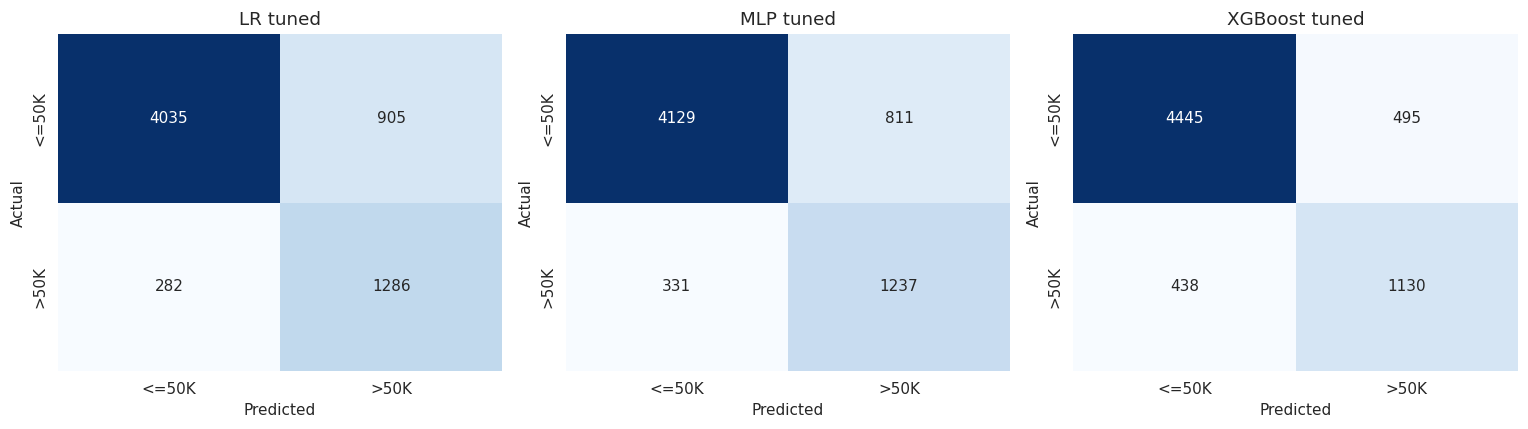

In [29]:
# confusion matrices for the three tuned models on the same test rows
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, name in zip(axes, ["LR tuned", "MLP tuned", "XGBoost tuned"]):
    cm = metrics.confusion_matrix(yte, test_pred[name])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
                xticklabels=["<=50K", ">50K"], yticklabels=["<=50K", ">50K"])
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()

- The three matrices show the same trade in different amounts. The logistic regression catches the most real high
earners but pays with the largest false alarm count.
- XGBoost moves many of those false alarms back into the correct cell while giving up some caught high earners, which
is why its precision and F1 are higher even though its raw recall is lower.
- The MLP sits between them and clearly beats neither, which is the pattern in every table below.

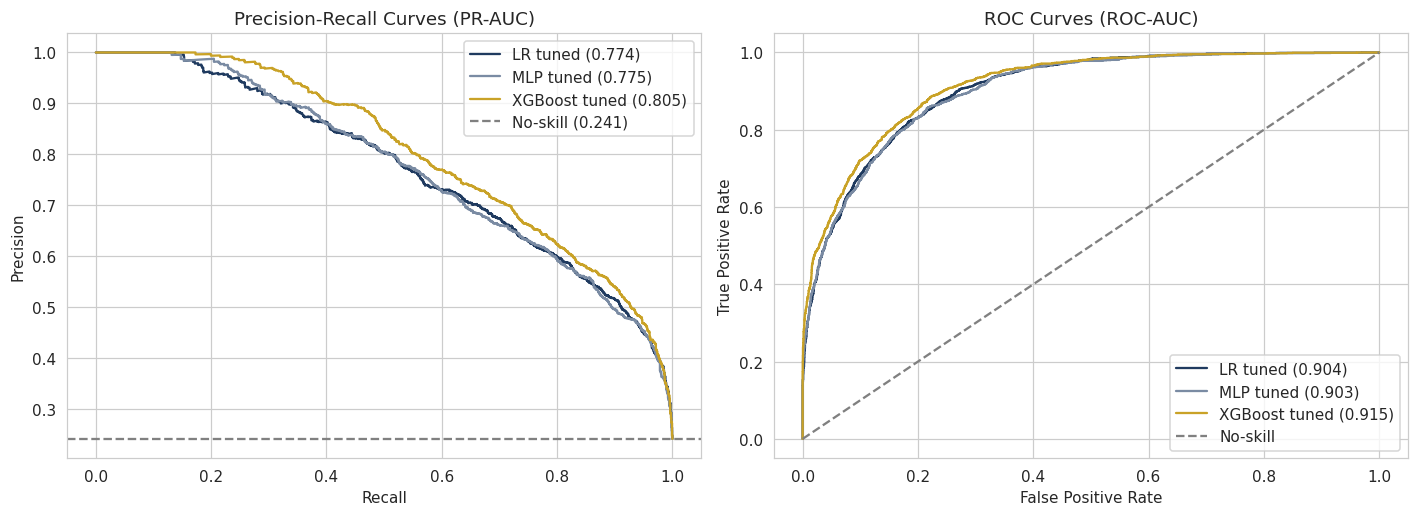

In [30]:
# precision-recall and ROC curves for all three models on the same test rows
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
for name, color in [("LR tuned", NAVY), ("MLP tuned", GREY), ("XGBoost tuned", GOLD)]:
    prec, rec, _ = metrics.precision_recall_curve(yte, test_prob[name])
    fpr, tpr, _ = metrics.roc_curve(yte, test_prob[name])
    axes[0].plot(rec, prec, color=color, label=f"{name} ({metrics.average_precision_score(yte, test_prob[name]):.3f})")
    axes[1].plot(fpr, tpr, color=color, label=f"{name} ({metrics.roc_auc_score(yte, test_prob[name]):.3f})")
axes[0].axhline(yte.mean(), color="grey", ls="--", label=f"No-skill ({yte.mean():.3f})")
axes[0].set_xlabel("Recall"); axes[0].set_ylabel("Precision"); axes[0].set_title("Precision-Recall Curves (PR-AUC)")
axes[0].legend()
axes[1].plot([0, 1], [0, 1], color="grey", ls="--", label="No-skill")
axes[1].set_xlabel("False Positive Rate"); axes[1].set_ylabel("True Positive Rate"); axes[1].set_title("ROC Curves (ROC-AUC)")
axes[1].legend()
plt.tight_layout()
plt.show()

- The precision-recall curves are the plot that matters. XGBoost sits above the other two across nearly the whole
recall range, so at any recall level it flags fewer people wrongly, and all three stay well above the 0.241 no-skill
line.
- The ROC curves are much closer together, which is the flattering behavior on imbalanced data: the large easy
negative class props all three up and hides a gap PR-AUC shows clearly. That is why PR-AUC is my lead metric.

- The test set confirms the validation ordering, which is what I want to see. A model that led on validation and fell
apart on test would mean I had overfit my tuning.
- XGBoost reaches 0.805 PR-AUC and 0.708 F1 against 0.774 and 0.684 for the tuned logistic regression, so it clears
the baseline on both metrics H3 names.
- Every model clears the naive floor by a wide margin, and the naive model's 0.759 accuracy is higher than the
logistic regression's, which is the clearest justification for not leading with accuracy.
- One thing to notice before the fairness section: XGBoost has the highest F1 but the lowest recall, 0.721 against
0.820. It trades caught high earners for far fewer false alarms, 495 against 905, so the three models are not at the
same operating point and their group gaps are not measured at the same recall.

## Bootstrap confidence intervals on the test results

- The fold-based intervals rest on five numbers. The bootstrap uses all 6,508 test rows, so it gives a much narrower
interval at the same confidence level.
- It resamples the test rows with replacement, recomputes the metric on each resample, and reads the 2.5th and 97.5th
percentiles as the interval. It assumes nothing about the shape of that distribution, which is why it works for
PR-AUC.
- The critical detail is that it is paired. Every model is scored on the identical resample, so I can take the
difference between two models inside a replicate and get an interval directly on that difference. Comparing two
separate intervals for overlap would be wrong, since overlapping intervals do not mean a difference is
non-significant.

In [31]:
# paired bootstrap over the test rows, scoring every model on the identical resample each time
def paired_bootstrap(y_true, probs, preds, n_boot=1000, seed=SEED):
    rng = np.random.RandomState(seed)
    y_arr = np.asarray(y_true)
    n = len(y_arr)
    keys = list(probs.keys())
    store = {k: {"PR-AUC": [], "F1": []} for k in keys}
    for _ in range(n_boot):
        idx = rng.randint(0, n, n)
        yb = y_arr[idx]
        if yb.sum() == 0:
            continue
        for k in keys:
            store[k]["PR-AUC"].append(metrics.average_precision_score(yb, probs[k][idx]))
            store[k]["F1"].append(metrics.f1_score(yb, preds[k][idx]))
    return {k: {m: np.array(v) for m, v in d.items()} for k, d in store.items()}

boot_models = ["LR tuned", "MLP tuned", "XGBoost tuned"]
boot = paired_bootstrap(yte, {k: test_prob[k] for k in boot_models}, {k: test_pred[k] for k in boot_models})
boot_rows = []
for k in boot_models:
    for m in ["PR-AUC", "F1"]:
        s = boot[k][m]
        lo, hi = np.percentile(s, [2.5, 97.5])
        boot_rows.append({"model": k, "metric": m, "estimate": s.mean(), "95% CI low": lo, "95% CI high": hi, "CI width": hi - lo})
print("Bootstrap 95 percent confidence intervals on the test set, 1000 resamples\n")
print(pd.DataFrame(boot_rows).round(4).to_string(index=False))

Bootstrap 95 percent confidence intervals on the test set, 1000 resamples

        model metric  estimate  95% CI low  95% CI high  CI width
     LR tuned PR-AUC    0.7743      0.7549       0.7920    0.0371
     LR tuned     F1    0.6838      0.6668       0.7003    0.0334
    MLP tuned PR-AUC    0.7750      0.7563       0.7931    0.0368
    MLP tuned     F1    0.6836      0.6652       0.7000    0.0349
XGBoost tuned PR-AUC    0.8052      0.7878       0.8217    0.0338
XGBoost tuned     F1    0.7076      0.6888       0.7250    0.0362


In [32]:
# the same bootstrap replicates turned into confidence intervals on the difference between two models
diff_rows = []
for m in ["PR-AUC", "F1"]:
    for a, b in [("XGBoost tuned", "LR tuned"), ("XGBoost tuned", "MLP tuned"), ("MLP tuned", "LR tuned")]:
        d = boot[a][m] - boot[b][m]
        lo, hi = np.percentile(d, [2.5, 97.5])
        diff_rows.append({"metric": m, "comparison": f"{a} minus {b}", "mean difference": d.mean(),
                          "95% CI low": lo, "95% CI high": hi, "CI width": hi - lo,
                          "excludes zero": "yes" if lo > 0 or hi < 0 else "no",
                          "share of resamples favoring first": (d > 0).mean()})
print("Paired bootstrap confidence intervals on the difference between models\n")
print(pd.DataFrame(diff_rows).round(4).to_string(index=False))

Paired bootstrap confidence intervals on the difference between models

metric                    comparison  mean difference  95% CI low  95% CI high  CI width excludes zero  share of resamples favoring first
PR-AUC  XGBoost tuned minus LR tuned           0.0309      0.0218       0.0402    0.0184           yes                              1.000
PR-AUC XGBoost tuned minus MLP tuned           0.0302      0.0221       0.0378    0.0157           yes                              1.000
PR-AUC      MLP tuned minus LR tuned           0.0007     -0.0071       0.0090    0.0161            no                              0.576
    F1  XGBoost tuned minus LR tuned           0.0238      0.0101       0.0368    0.0267           yes                              1.000
    F1 XGBoost tuned minus MLP tuned           0.0240      0.0123       0.0367    0.0244           yes                              1.000
    F1      MLP tuned minus LR tuned          -0.0002     -0.0103       0.0105    0.0208            

In [33]:
# McNemar's test on the rows where two models disagree, the right paired test for one shared test set
def mcnemar_exact(y_true, pred_a, pred_b):
    a_right = pred_a == np.asarray(y_true)
    b_right = pred_b == np.asarray(y_true)
    b_cell = int((a_right & ~b_right).sum())
    c_cell = int((~a_right & b_right).sum())
    p = stats.binomtest(b_cell, b_cell + c_cell, 0.5).pvalue if (b_cell + c_cell) > 0 else 1.0
    return b_cell, c_cell, p

mc_rows = []
for a, b in [("XGBoost tuned", "LR tuned"), ("XGBoost tuned", "MLP tuned"), ("MLP tuned", "LR tuned")]:
    only_a, only_b, p = mcnemar_exact(yte, test_pred[a], test_pred[b])
    mc_rows.append({"comparison": f"{a} vs {b}", "rows only first got right": only_a,
                    "rows only second got right": only_b, "discordant pairs": only_a + only_b,
                    "exact p-value": p, "significant at 0.05": "yes" if p < 0.05 else "no"})
print("McNemar's exact test on the 6,508 shared test rows\n")
print(pd.DataFrame(mc_rows).to_string(index=False))

McNemar's exact test on the 6,508 shared test rows

                comparison  rows only first got right  rows only second got right  discordant pairs  exact p-value significant at 0.05
 XGBoost tuned vs LR tuned                        454                         200               654   1.216058e-23                 yes
XGBoost tuned vs MLP tuned                        373                         164               537   9.618393e-20                 yes
     MLP tuned vs LR tuned                        272                         227               499   4.876280e-02                 yes


- The three tests agree on the XGBoost comparisons and disagree on the MLP comparison, and that disagreement is the
useful part.
- For XGBoost against either model, the paired t-test is significant, the bootstrap interval on the difference
excludes zero, XGBoost won in 1000 of 1000 resamples, and McNemar returns a p-value far below any threshold, with 454
rows fixed against 200 broken. Four independent readings agreeing is about as settled as this dataset allows.
- The MLP against the logistic regression is less clear. The fold t-test says p = 0.012, McNemar says
0.049 which is barely under the line, and the bootstrap interval runs from -0.007 to 0.009 and contains zero.
- When tests disagree I go with the one that has the most data and the fewest assumptions, which is the bootstrap. So
my reading is that the MLP and the logistic regression are not meaningfully different here, and the extra complexity
bought nothing over a linear model.

### Stating the two claims separately

- The guidelines ask me to state whether my model beats the baseline and whether that difference is significant, and
to treat those as two separate claims that each need evidence.

Claim one: does XGBoost beat the baseline?

- Yes. On the test set XGBoost reaches 0.805 PR-AUC against 0.773 for the untuned baseline and 0.774 for the tuned
one, and 0.708 F1 against 0.682 and 0.684. It also beats the naive floor at 0.241 PR-AUC.
- That is a claim about point estimates only. It says the numbers came out higher and nothing more.

Claim two: is that difference statistically significant?

- Yes, and it needs its own evidence, because a higher number could come from which rows landed in the test set. The
paired t-test gives p = 0.0002 on PR-AUC, McNemar gives p on the order of 1e-23, and the bootstrap interval on the
difference is 0.022 to 0.040, excluding zero, with XGBoost winning 1000 of 1000 resamples.

- The MLP is where the two claims come apart, which is why separating them matters. Claim one is technically yes, since
its 0.775 is a hair above the baseline's 0.773. Claim two is no: the bootstrap interval contains zero. A model can
post a higher number and still have no demonstrated advantage.

## Fairness audit: performance split by group

- This is where H2 gets tested and where I deal with the two group imbalances. About 90 percent of the people are
US-born and about 67 percent are men, so both minority groups are seen far less often during training.
- I audit on recall inside each group on real high earners, because that is the error that hurts the person rather
than the lender. If a model misses more of one group's high earners, it works worse for that group.
- I measure the gap two ways: on the test set as one number per model with a bootstrap interval, and across the
cross-validation folds as five paired numbers per model, which lets me test the gap itself.
- I report accuracy by group as well but do not lead with it. Every model is more accurate inside the foreign-born
group and far more accurate on women, which would read as the model serving them better. It is not. Those groups have
fewer high earners to find, so predicting under \$50K is right more often.

In [34]:
# group sizes and base rates in the test set, so the audit numbers below have their context attached
audit_ctx = []
for gname, gvals, levels in [("nativity", grp_nat, ["US", "non-US"]), ("sex", grp_sex, ["Male", "Female"])]:
    for lev in levels:
        mask = (gvals.loc[Xte.index] == lev).to_numpy()
        audit_ctx.append({"grouping": gname, "group": lev, "test rows": int(mask.sum()),
                          "share of test set": mask.mean(), "true >50K rate": yte[mask].mean(),
                          "real high earners": int(yte[mask].sum())})
print(pd.DataFrame(audit_ctx).round(3).to_string(index=False))

grouping  group  test rows  share of test set  true >50K rate  real high earners
nativity     US       5819              0.894           0.247               1436
nativity non-US        576              0.089           0.172                 99
     sex   Male       4335              0.666           0.306               1327
     sex Female       2173              0.334           0.111                241


In [35]:
# recall and accuracy inside each group on the test set, for all three tuned models
def group_report(gvals, levels, models):
    rows = []
    g_test = gvals.loc[Xte.index]
    for name in models:
        r = {"model": name}
        for lev in levels:
            mask = (g_test == lev).to_numpy()
            r[f"recall {lev}"] = metrics.recall_score(yte[mask], test_pred[name][mask])
            r[f"accuracy {lev}"] = metrics.accuracy_score(yte[mask], test_pred[name][mask])
        r["recall gap"] = r[f"recall {levels[0]}"] - r[f"recall {levels[1]}"]
        rows.append(r)
    return pd.DataFrame(rows).set_index("model")

nat_report = group_report(grp_nat, ["US", "non-US"], boot_models)
sex_report = group_report(grp_sex, ["Male", "Female"], boot_models)
print("Nativity split on the test set\n")
print(nat_report.round(3).to_string())
print("\nSex split on the test set\n")
print(sex_report.round(3).to_string())

Nativity split on the test set

               recall US  accuracy US  recall non-US  accuracy non-US  recall gap
model                                                                            
LR tuned           0.823        0.816          0.768            0.844       0.055
MLP tuned          0.793        0.823          0.747            0.851       0.046
XGBoost tuned      0.726        0.855          0.646            0.882       0.079

Sex split on the test set

               recall Male  accuracy Male  recall Female  accuracy Female  recall gap
model                                                                                
LR tuned             0.836          0.766          0.730            0.920       0.106
MLP tuned            0.806          0.775          0.697            0.924       0.108
XGBoost tuned        0.743          0.818          0.598            0.935       0.146


In [36]:
# paired bootstrap on the recall gap itself, so each gap gets an interval and each pair of models gets a difference
def gap_bootstrap(gvals, levels, models, n_boot=1000, seed=SEED):
    rng = np.random.RandomState(seed)
    g_test = (gvals.loc[Xte.index] == levels[0]).to_numpy()
    y_arr = np.asarray(yte)
    n = len(y_arr)
    store = {m: [] for m in models}
    for _ in range(n_boot):
        idx = rng.randint(0, n, n)
        yb, gb = y_arr[idx], g_test[idx]
        in_a = gb & (yb == 1)
        in_b = (~gb) & (yb == 1)
        if in_a.sum() < 5 or in_b.sum() < 5:
            continue
        for m in models:
            pb = test_pred[m][idx]
            store[m].append(pb[in_a].mean() - pb[in_b].mean())
    return {m: np.array(v) for m, v in store.items()}

nat_gap_boot = gap_bootstrap(grp_nat, ["US", "non-US"], boot_models)
sex_gap_boot = gap_bootstrap(grp_sex, ["Male", "Female"], boot_models)
gap_rows = []
for label, store in [("US minus non-US", nat_gap_boot), ("Male minus Female", sex_gap_boot)]:
    for m in boot_models:
        lo, hi = np.percentile(store[m], [2.5, 97.5])
        gap_rows.append({"gap": label, "model": m, "estimate": store[m].mean(), "95% CI low": lo,
                         "95% CI high": hi, "CI width": hi - lo,
                         "gap is real (excludes zero)": "yes" if lo > 0 or hi < 0 else "no"})
print("Bootstrap 95 percent confidence intervals on each model's recall gap\n")
print(pd.DataFrame(gap_rows).round(4).to_string(index=False))

Bootstrap 95 percent confidence intervals on each model's recall gap

              gap         model  estimate  95% CI low  95% CI high  CI width gap is real (excludes zero)
  US minus non-US      LR tuned    0.0336     -0.0369       0.1110    0.1479                          no
  US minus non-US     MLP tuned    0.0498     -0.0233       0.1287    0.1520                          no
  US minus non-US XGBoost tuned    0.0588     -0.0246       0.1461    0.1707                          no
Male minus Female      LR tuned    0.1062      0.0503       0.1627    0.1125                         yes
Male minus Female     MLP tuned    0.1094      0.0497       0.1708    0.1212                         yes
Male minus Female XGBoost tuned    0.1460      0.0813       0.2134    0.1321                         yes


In [37]:
# the difference between two models' gaps, taken inside each bootstrap replicate so the comparison stays paired
gap_diff_rows = []
for label, store in [("US minus non-US", nat_gap_boot), ("Male minus Female", sex_gap_boot)]:
    for a, b in [("XGBoost tuned", "LR tuned"), ("XGBoost tuned", "MLP tuned"), ("MLP tuned", "LR tuned")]:
        d = np.abs(store[a]) - np.abs(store[b])
        lo, hi = np.percentile(d, [2.5, 97.5])
        gap_diff_rows.append({"gap": label, "comparison": f"|{a}| minus |{b}|", "mean difference": d.mean(),
                              "95% CI low": lo, "95% CI high": hi,
                              "excludes zero": "yes" if lo > 0 or hi < 0 else "no",
                              "share of resamples where first is smaller": (d < 0).mean()})
print("Is one model's gap really smaller than another's, paired inside each resample\n")
print(pd.DataFrame(gap_diff_rows).round(4).to_string(index=False))

Is one model's gap really smaller than another's, paired inside each resample

              gap                        comparison  mean difference  95% CI low  95% CI high excludes zero  share of resamples where first is smaller
  US minus non-US  |XGBoost tuned| minus |LR tuned|           0.0211     -0.0337       0.0884            no                                      0.275
  US minus non-US |XGBoost tuned| minus |MLP tuned|           0.0087     -0.0459       0.0653            no                                      0.393
  US minus non-US      |MLP tuned| minus |LR tuned|           0.0123     -0.0362       0.0655            no                                      0.326
Male minus Female  |XGBoost tuned| minus |LR tuned|           0.0398     -0.0133       0.0910            no                                      0.069
Male minus Female |XGBoost tuned| minus |MLP tuned|           0.0366     -0.0131       0.0867            no                                      0.074
Male minus Fema

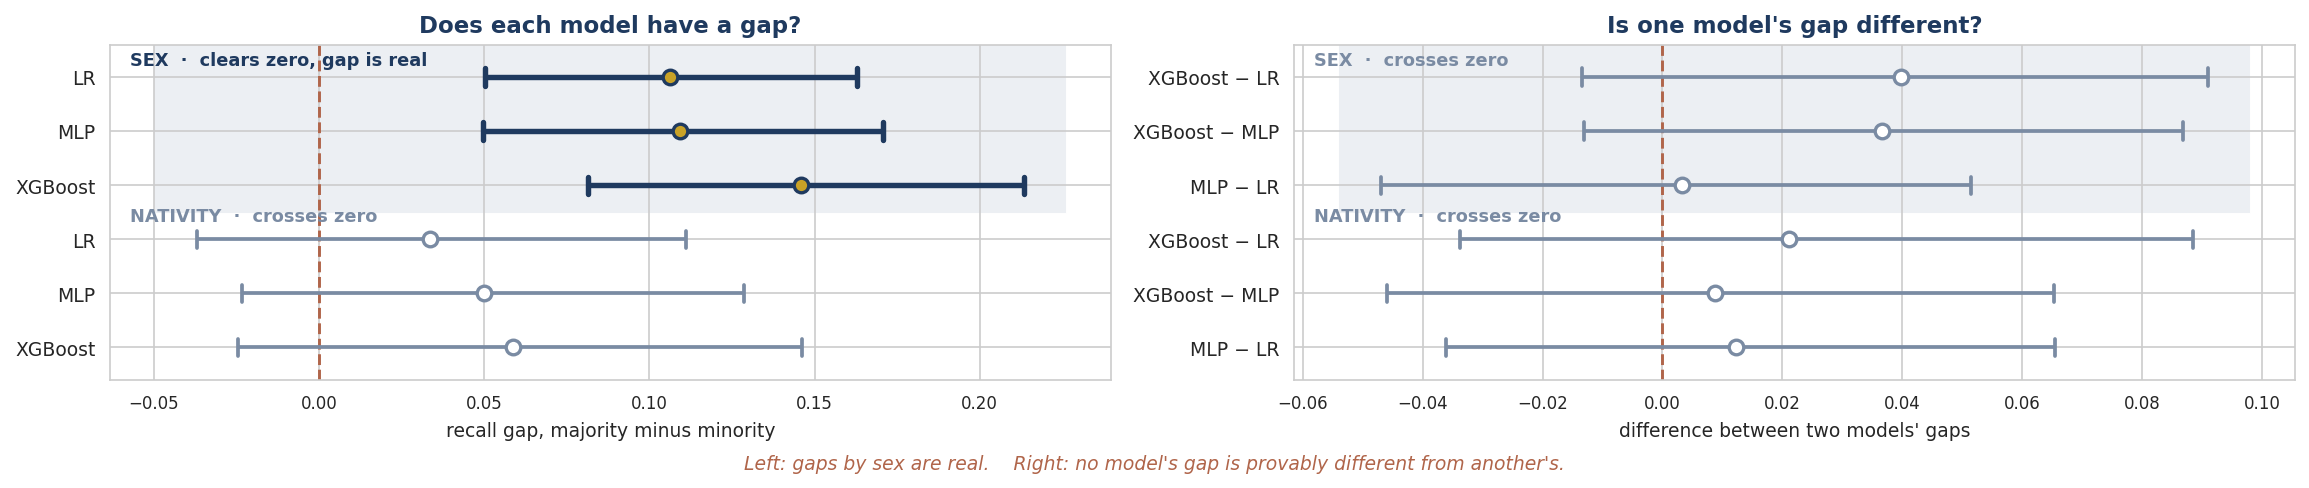

In [38]:
# the same gaps as a forest plot: each model's interval on the left, and the difference between two models' gaps on the right
short = {"LR tuned": "LR", "MLP tuned": "MLP", "XGBoost tuned": "XGBoost"}
pairs = [("XGBoost tuned", "LR tuned"), ("XGBoost tuned", "MLP tuned"), ("MLP tuned", "LR tuned")]

def forest_panel(ax, series, labels, title, xlabel):
    y = np.arange(len(series))[::-1]
    for yi, vals in zip(y, series):
        lo, hi = np.percentile(vals, [2.5, 97.5])
        real = lo > 0 or hi < 0                      # colour marks intervals that exclude zero
        col = NAVY if real else GREY
        ax.plot([lo, hi], [yi, yi], color=col, lw=2.6 if real else 1.8, zorder=2)
        for x in (lo, hi):
            ax.plot([x, x], [yi - 0.16, yi + 0.16], color=col, lw=2.6 if real else 1.8, zorder=2)
        ax.plot(vals.mean(), yi, "o", ms=7, zorder=3,
                mfc=GOLD if real else "white", mec=col, mew=1.6)
    ax.axvspan(*ax.get_xlim(), ymin=0.5, ymax=1.0, color="#eceff3", zorder=0)
    ax.axvline(0, color=RUST, ls="--", lw=1.4, zorder=1)
    ax.set_yticks(y); ax.set_yticklabels(labels, fontsize=9)
    ax.set_title(title, fontsize=11, fontweight="bold", color=NAVY)
    ax.set_xlabel(xlabel, fontsize=9)
    ax.tick_params(axis="x", labelsize=8)
    ax.set_ylim(-0.6, len(series) - 0.4)

fig, axes = plt.subplots(1, 2, figsize=(15.5, 3.12))

# left: does each model have a gap at all, sex block on top and nativity below
left = [sex_gap_boot[m] for m in boot_models] + [nat_gap_boot[m] for m in boot_models]
forest_panel(axes[0], left, [short[m] for m in boot_models] * 2,
             "Does each model have a gap?", "recall gap, majority minus minority")

# right: is one model's gap smaller than another's, taken inside each resample
right = [np.abs(sex_gap_boot[a]) - np.abs(sex_gap_boot[b]) for a, b in pairs] + \
        [np.abs(nat_gap_boot[a]) - np.abs(nat_gap_boot[b]) for a, b in pairs]
forest_panel(axes[1], right, [f"{short[a]} \u2212 {short[b]}" for a, b in pairs] * 2,
             "Is one model's gap different?", "difference between two models' gaps")

for ax, sex_note in zip(axes, ["SEX  \u00b7  clears zero, gap is real", "SEX  \u00b7  crosses zero"]):
    x0 = ax.get_xlim()[0] + 0.02 * (ax.get_xlim()[1] - ax.get_xlim()[0])
    ax.text(x0, 5.32, sex_note, fontsize=8.5, fontweight="bold",
            color=NAVY if ax is axes[0] else GREY, va="center")
    ax.text(x0, 2.42, "NATIVITY  \u00b7  crosses zero", fontsize=8.5,
            fontweight="bold", color=GREY, va="center")

fig.text(0.5, -0.02, "Left: gaps by sex are real.    Right: no model's gap is provably different from another's.",
         ha="center", fontsize=9, style="italic", color=RUST)
plt.tight_layout()
plt.show()


- The point estimates say the opposite of what H2 predicted. XGBoost has the largest nativity gap at 0.079, against
0.055 for the logistic regression and 0.046 for the MLP, and the same ordering shows up on sex, at 0.146 against
0.106 and 0.108.
- The confidence intervals are where the honesty comes in. Every nativity gap interval contains zero, including
XGBoost's at -0.025 to 0.146, so I cannot claim any model has a nativity gap distinguishable from no gap at all.
- The sex gaps are different. All three intervals exclude zero, so those gaps are real: every model finds male high
earners more reliably than female ones, by about 11 to 15 points.
- The comparison between models is not settled on either axis, since no interval on a difference between two models'
gaps excludes zero. The direction leans against H2, with XGBoost's gap smaller than the baseline's in only 6.9
percent of resamples on sex and 27.5 percent on nativity, but leaning is not showing.

In [39]:
# the same gaps measured across the five identical cross-validation folds, then tested as paired samples
cv_scores["nat gap"] = cv_scores["rec_US"] - cv_scores["rec_non-US"]
cv_scores["sex gap"] = cv_scores["rec_Male"] - cv_scores["rec_Female"]
cv_gap_summary = cv_scores.groupby("model")[["rec_US", "rec_non-US", "nat gap", "rec_Male", "rec_Female", "sex gap"]].agg(["mean", "std"])
print("Per-group recall across the five cross-validation folds\n")
print(cv_gap_summary.round(4).to_string())
gap_test_rows = []
for col in ["nat gap", "sex gap"]:
    wide = cv_scores.pivot(index="fold", columns="model", values=col).abs()
    for a, b in [("XGBoost", "LR"), ("XGBoost", "MLP"), ("MLP", "LR")]:
        t_stat, t_p = stats.ttest_rel(wide[a], wide[b])
        w_stat, w_p = stats.wilcoxon(wide[a], wide[b])
        gap_test_rows.append({"gap": col, "comparison": f"{a} vs {b}", "mean diff in gap size": (wide[a] - wide[b]).mean(),
                              "t": t_stat, "t p-value": t_p, "wilcoxon p-value": w_p,
                              "significant at 0.05": "yes" if t_p < 0.05 else "no"})
print("\nPaired tests on the fairness gap itself, across the same five folds\n")
print(pd.DataFrame(gap_test_rows).round(4).to_string(index=False))

Per-group recall across the five cross-validation folds

         rec_US         rec_non-US         nat gap         rec_Male         rec_Female         sex gap        
           mean     std       mean     std    mean     std     mean     std       mean     std    mean     std
model                                                                                                         
LR       0.8433  0.0186     0.7819  0.0725  0.0614  0.0729   0.8613  0.0185     0.7033  0.0640  0.1580  0.0682
MLP      0.8424  0.0248     0.7518  0.0870  0.0906  0.0734   0.8575  0.0289     0.7083  0.0435  0.1492  0.0502
XGBoost  0.7455  0.0161     0.6663  0.0550  0.0792  0.0647   0.7613  0.0069     0.6118  0.0736  0.1495  0.0735

Paired tests on the fairness gap itself, across the same five folds

    gap     comparison  mean diff in gap size       t  t p-value  wilcoxon p-value significant at 0.05
nat gap  XGBoost vs LR                 0.0115  1.8760     0.1339            0.1250                  no
n

In [40]:
# how much more data it would take to settle H2, since the interval width shrinks with the square root of the sample size
n_pos_foreign = int(yte[(grp_nat.loc[Xte.index] == "non-US").to_numpy()].sum())
current_width = float(np.percentile(nat_gap_boot["XGBoost tuned"], 97.5) - np.percentile(nat_gap_boot["XGBoost tuned"], 2.5))
need_rows = []
for target in [0.05, 0.02]:
    factor = (current_width / target) ** 2
    need_rows.append({"target CI width": target, "sample size multiple needed": round(factor, 1),
                      "foreign-born high earners needed": int(round(n_pos_foreign * factor))})
print("Foreign-born high earners in the test set:", n_pos_foreign)
print("Current 95 percent CI width on the XGBoost nativity gap:", round(current_width, 4), "\n")
print(pd.DataFrame(need_rows).to_string(index=False))

Foreign-born high earners in the test set: 99
Current 95 percent CI width on the XGBoost nativity gap: 0.1707 

 target CI width  sample size multiple needed  foreign-born high earners needed
            0.05                         11.6                              1153
            0.02                         72.8                              7208


- This is the interval width point made concrete. The nativity gap rests on only 99 real foreign-born high earners,
and with that little to work with the 95 percent interval spans about 0.17, wider than any gap I could plausibly
find. The interval is wide because the group is small, not because the models are unstable.
- Since width shrinks with the square root of the sample size, cutting it to a usable 0.05 would take roughly 11
times as many foreign-born high earners, on the order of 1,100 instead of 99. That is not available here.
- So the conclusion is not that the models have equal nativity gaps. It is that this dataset cannot tell them apart,
and reporting a point estimate without that caveat would be the mistake. The sex comparison has 241 female high
earners, which is already enough for the gaps themselves to come out significant.

## Handling the group imbalance

- Finding a gap is half the job. The other half is trying to close it and measuring what that costs. I test three
approaches against the as-is model, on both group axes.
- Training on the minority group only. Every model above is trained on data where one group dominates, so the
question is whether the gap is simply the model not seeing enough of the smaller group. If so, a model that sees
nothing else should fix it.
- Group-balanced oversampling. I upsample the minority group's training rows with replacement until both groups are
equally represented, which keeps all the majority data while removing the representation imbalance.
- Group-specific decision thresholds. The 0.5 cutoff is a choice, not a fact, so I pick a separate cutoff per
group on the validation set to bring both to a similar recall, then apply those to the test set. This retrains
nothing, it just stops using one cutoff for two groups whose score distributions differ.
- Thresholds are chosen on validation only, so this stays an honest comparison.

In [41]:
# train each model three more ways per group axis: on the minority group only, on group-balanced data, and with group thresholds
def group_threshold_for(model, gvals, levels, target_recall):
    thr = {}
    g_val = gvals.loc[Xval.index]
    prob_val = model.predict_proba(Xval)[:, 1]
    for lev in levels:
        mask = (g_val == lev).to_numpy()
        yv, pv = yval[mask].to_numpy(), prob_val[mask]
        grid = np.linspace(0.05, 0.95, 91)
        recs = np.array([(pv[yv == 1] >= t).mean() for t in grid])
        ok = grid[recs >= target_recall]
        thr[lev] = ok.max() if len(ok) else 0.05
    return thr

def mitigation_table(gvals, levels, target_recall):
    g_tr, g_val, g_te = gvals.loc[Xtr.index], gvals.loc[Xval.index], gvals.loc[Xte.index]
    minority = levels[1]
    min_mask = (g_tr == minority).to_numpy()
    maj_mask = (g_tr == levels[0]).to_numpy()
    rng = np.random.RandomState(SEED)
    boost = rng.choice(np.where(min_mask)[0], size=int(maj_mask.sum() - min_mask.sum()), replace=True)
    bal_idx = np.concatenate([np.arange(len(Xtr)), boost])
    rows = []
    for name, params, builder in [("LR", lr_best, lr_pipe), ("XGBoost", xgb_best, xgb_pipe), ("MLP", mlp_best, mlp_pipe)]:
        base = tuned[{"LR": "LR", "XGBoost": "XGBoost", "MLP": "MLP"}[name]]
        variants = {"as-is (full data)": base,
                    "minority group only": builder(**params).fit(Xtr[min_mask], ytr[min_mask]),
                    "group-balanced oversample": builder(**params).fit(Xtr.iloc[bal_idx], ytr.iloc[bal_idx])}
        thr = group_threshold_for(base, gvals, levels, target_recall)
        for label, m in variants.items():
            pred = m.predict(Xte)
            r = {"model": name, "strategy": label}
            for lev in levels:
                mask = (g_te == lev).to_numpy()
                r[f"recall {lev}"] = metrics.recall_score(yte[mask], pred[mask])
            r["gap"] = r[f"recall {levels[0]}"] - r[f"recall {levels[1]}"]
            r["overall F1"] = metrics.f1_score(yte, pred)
            rows.append(r)
        prob_te = base.predict_proba(Xte)[:, 1]
        pred_thr = np.zeros(len(yte), dtype=int)
        for lev in levels:
            mask = (g_te == lev).to_numpy()
            pred_thr[mask] = (prob_te[mask] >= thr[lev]).astype(int)
        r = {"model": name, "strategy": f"group thresholds {({k: round(v,2) for k,v in thr.items()})}"}
        for lev in levels:
            mask = (g_te == lev).to_numpy()
            r[f"recall {lev}"] = metrics.recall_score(yte[mask], pred_thr[mask])
        r["gap"] = r[f"recall {levels[0]}"] - r[f"recall {levels[1]}"]
        r["overall F1"] = metrics.f1_score(yte, pred_thr)
        rows.append(r)
    return pd.DataFrame(rows).set_index(["model", "strategy"])

nat_mitigation = mitigation_table(grp_nat, ["US", "non-US"], 0.80)
print("Nativity: four ways of handling the imbalance, all scored on the test set\n")
print(nat_mitigation.round(3).to_string())

Nativity: four ways of handling the imbalance, all scored on the test set

                                                                               recall US  recall non-US    gap  overall F1
model   strategy                                                                                                          
LR      as-is (full data)                                                          0.823          0.768  0.055       0.684
        minority group only                                                        0.930          0.768  0.162       0.617
        group-balanced oversample                                                  0.838          0.778  0.060       0.669
        group thresholds {'US': np.float64(0.56), 'non-US': np.float64(0.45)}      0.779          0.798 -0.019       0.675
XGBoost as-is (full data)                                                          0.726          0.646  0.079       0.708
        minority group only                                     

In [42]:
# the same four strategies for the male versus female imbalance
sex_mitigation = mitigation_table(grp_sex, ["Male", "Female"], 0.80)
print("Sex: four ways of handling the imbalance, all scored on the test set\n")
print(sex_mitigation.round(3).to_string())

Sex: four ways of handling the imbalance, all scored on the test set

                                                                                 recall Male  recall Female    gap  overall F1
model   strategy                                                                                                              
LR      as-is (full data)                                                              0.836          0.730  0.106       0.684
        minority group only                                                            0.887          0.842  0.045       0.629
        group-balanced oversample                                                      0.864          0.776  0.088       0.674
        group thresholds {'Male': np.float64(0.59), 'Female': np.float64(0.4)}         0.767          0.805 -0.038       0.681
XGBoost as-is (full data)                                                              0.743          0.598  0.146       0.708
        minority group only              

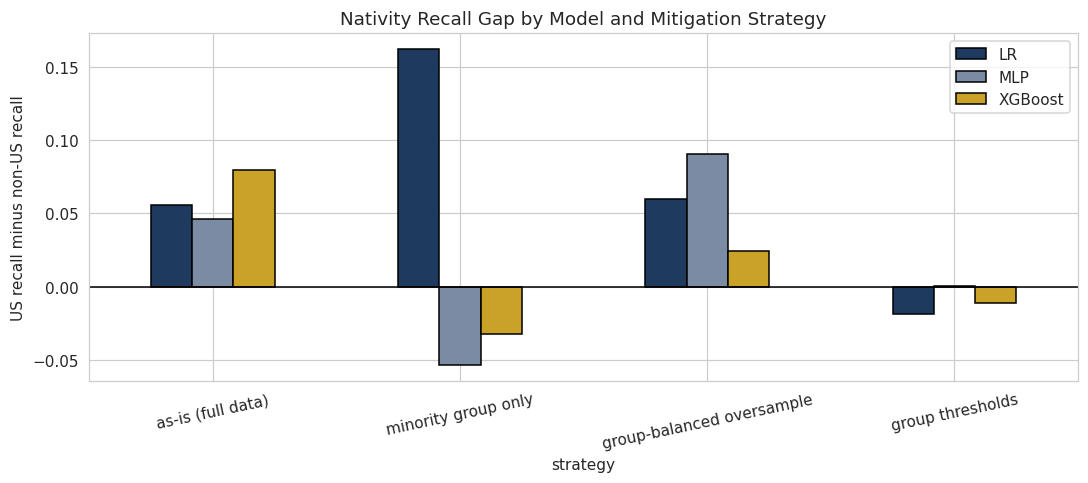

In [43]:
# the nativity recall gap for every model and strategy in one chart
plot_gaps = nat_mitigation.reset_index()
plot_gaps["strategy"] = plot_gaps["strategy"].str.replace(r"group thresholds.*", "group thresholds", regex=True)
pivot_gaps = plot_gaps.pivot(index="strategy", columns="model", values="gap")
pivot_gaps = pivot_gaps.reindex(["as-is (full data)", "minority group only", "group-balanced oversample", "group thresholds"])
pivot_gaps.plot(kind="bar", figsize=(10, 4.5), color=[NAVY, GREY, GOLD], edgecolor="black")
plt.axhline(0, color="black", lw=1)
plt.ylabel("US recall minus non-US recall")
plt.title("Nativity Recall Gap by Model and Mitigation Strategy")
plt.xticks(rotation=12)
plt.legend(title="")
plt.tight_layout()
plt.show()

- Training on the minority group only is the worst of the four, and it fails instructively. The foreign-born model
has 1,680 training rows against 19,521, and the female-only XGBoost collapses to 0.375 recall on men and 0.549 F1.
Cutting the data down to the group did not fix the gap, it moved which group gets served badly. So the gap is not
simply a matter of the model never seeing enough of the smaller group.
- Group-balanced oversampling is the mild version and works better because it keeps everything. For XGBoost it cuts
the nativity gap from 0.079 to 0.024 and the sex gap from 0.146 to 0.099, at an F1 cost of about 0.002. Close to
free.
- Group-specific thresholds are the most effective. They close the nativity gap to within a point of zero for all
three models at a cost of 0.708 down to 0.696 F1 for XGBoost. That works because the imbalance is mostly about where
one cutoff falls on two different score distributions, and moving the cutoff per group is the direct fix.
- The caveat is that a group-specific threshold means explicitly using nativity or sex to decide an outcome, which in
a real lending setting is very likely illegal under fair lending rules regardless of intent. So my recommendation is
group-balanced oversampling, which fixes much of the gap without the model branching on a protected attribute at
prediction time, and the thresholds are best read as a diagnostic.
- That diagnostic changes how H2 should be read. Once the thresholds put all three models at a matched recall of
about 0.78, XGBoost's nativity gap is -0.011 and it still has the highest F1. Its larger raw gap is partly a
consequence of operating at a lower recall, not evidence that it treats the groups more differently.

## Testing the hypotheses

- Each hypothesis gets its own verdict below, and each verdict has to rest on a test and an interval, not on a number being larger than another.

### H1: education drives the prediction more than hours worked

- The test is permutation importance on the test set, scored on PR-AUC. Shuffling a feature's values breaks its
relationship with the target while leaving everything else intact, so the drop in PR-AUC measures how much the model
leaned on it.
- One detail matters for fairness between the two. Education is one column, but hours is hours_per_week plus the six
hours_group dummies I engineered, and shuffling only hours_per_week would leave those dummies telling the model the
answer. So I shuffle the whole hours block together with one shared permutation order.
- I repeat 20 times per feature and use the spread across repeats to build a confidence interval on the difference,
so the claim is that education beats hours by an amount whose interval excludes zero, not just that its bar is
taller.
- I run this on all three models, because a claim about which feature matters should not depend on which model I
picked.

In [44]:
# permutation importance on the test set, shuffling the whole hours block together so hours gets a fair comparison
def block_permutation_importance(model, X_, y_, cols, n_repeats=20, seed=SEED):
    rng = np.random.RandomState(seed)
    base = metrics.average_precision_score(y_, model.predict_proba(X_)[:, 1])
    drops = []
    for _ in range(n_repeats):
        Xp = X_.copy()
        order = rng.permutation(len(Xp))
        for c in cols:
            Xp[c] = Xp[c].to_numpy()[order]
        drops.append(base - metrics.average_precision_score(y_, model.predict_proba(Xp)[:, 1]))
    return np.array(drops)

edu_cols = ["education_num"]
hrs_cols = ["hours_per_week"] + [c for c in X.columns if c.startswith("hours_group_")]
h1_rows = []
for name in ["LR", "XGBoost", "MLP"]:
    edu = block_permutation_importance(tuned[name], Xte, yte, edu_cols)
    hrs = block_permutation_importance(tuned[name], Xte, yte, hrs_cols)
    d = edu - hrs
    lo, hi = stats.t.interval(0.95, len(d) - 1, loc=d.mean(), scale=stats.sem(d))
    t_stat, t_p = stats.ttest_rel(edu, hrs)
    h1_rows.append({"model": name, "education drop": edu.mean(), "hours drop": hrs.mean(),
                    "difference": d.mean(), "95% CI low": lo, "95% CI high": hi,
                    "t": t_stat, "p-value": t_p, "education wins": "yes" if lo > 0 else "no"})
h1_table = pd.DataFrame(h1_rows).set_index("model")
print("H1: permutation importance on PR-AUC, education against the whole hours block, 20 repeats each\n")
print(h1_table.round(4).to_string())

H1: permutation importance on PR-AUC, education against the whole hours block, 20 repeats each

         education drop  hours drop  difference  95% CI low  95% CI high        t  p-value education wins
model                                                                                                    
LR               0.0729      0.0288      0.0441      0.0415       0.0467  35.5892      0.0            yes
XGBoost          0.0588      0.0196      0.0392      0.0374       0.0411  44.2253      0.0            yes
MLP              0.0692      0.0251      0.0441      0.0415       0.0467  35.6172      0.0            yes


- H1 is supported on all three models, and the agreement across models is what makes it convincing instead of a quirk of one algorithm.
- Shuffling education costs the logistic regression 0.073 of PR-AUC against 0.029 for the hours block. XGBoost loses
0.059 against 0.020 and the MLP 0.069 against 0.025, so education is worth roughly two and a half to three times as
much to every model.
- The 95 percent intervals on the difference are 0.042 to 0.047, 0.037 to 0.041, and 0.042 to 0.047, all excluding
zero by a wide margin, so this is not a case where a taller bar could be noise.
- This is the fourth independent method to give the same answer, after the raw rate spread, the decision tree
importance, and the Cohen's d effect sizes from the EDA milestone.
- What H1 does not claim is that education is the most important feature overall. Capital gain and marital status
outrank it on every model. H1 is a claim about education against hours specifically.

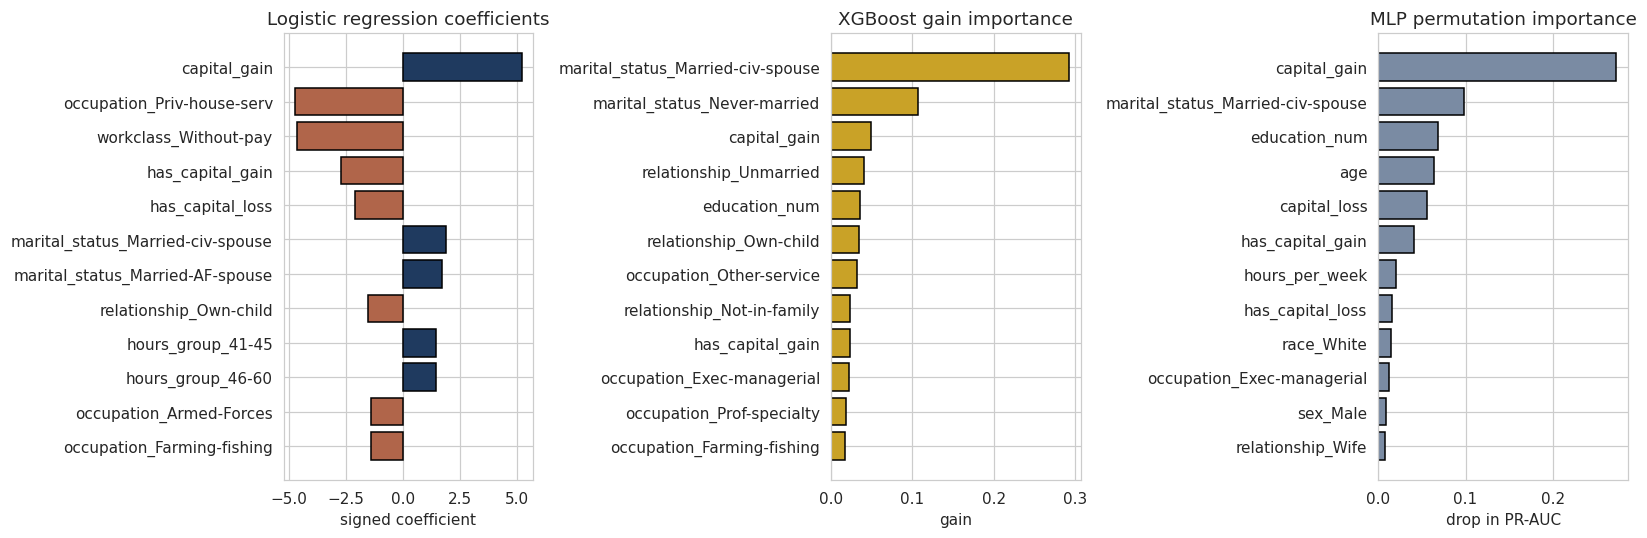

In [45]:
# what each model thinks matters most, using the importance measure that is native to it
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
coefs = pd.Series(tuned["LR"].named_steps["clf"].coef_[0], index=list(X.columns)).sort_values(key=abs, ascending=False).head(12)[::-1]
axes[0].barh(coefs.index, coefs.values, color=[NAVY if v > 0 else RUST for v in coefs.values], edgecolor="black")
axes[0].set_title("Logistic regression coefficients")
axes[0].set_xlabel("signed coefficient")
gain = pd.Series(tuned["XGBoost"].named_steps["clf"].feature_importances_, index=list(X.columns)).sort_values(ascending=False).head(12)[::-1]
axes[1].barh(gain.index, gain.values, color=GOLD, edgecolor="black")
axes[1].set_title("XGBoost gain importance")
axes[1].set_xlabel("gain")
from sklearn.inspection import permutation_importance
perm = permutation_importance(tuned["MLP"], Xte, yte, scoring="average_precision", n_repeats=3, random_state=SEED)
pi = pd.Series(perm.importances_mean, index=list(X.columns)).sort_values(ascending=False).head(12)[::-1]
axes[2].barh(pi.index, pi.values, color=GREY, edgecolor="black")
axes[2].set_title("MLP permutation importance")
axes[2].set_xlabel("drop in PR-AUC")
plt.tight_layout()
plt.show()

- The three panels use the measure that is native to each model, so they are not on the same scale and I do not read
the exact heights against each other. What I read is the ordering inside each panel.
- Capital gain and marital status dominate all three, which matches the decision tree I fit in the EDA milestone.
- Education sits well above hours in every panel, and the formal test is the table above and not these bars, because
a bar chart cannot tell me whether the gap is bigger than the noise.

### H2: XGBoost has the smallest nativity recall gap

- H2 is refuted. XGBoost has the largest raw nativity gap of the three at 0.079, not the smallest, against 0.055 for
the logistic regression and 0.046 for the MLP, and the same ordering appears on sex. The hypothesis predicted the
opposite direction.
- The more careful statement is that no model is statistically distinguishable from any other on this gap. Every
bootstrap interval on a difference contains zero and the paired fold tests return p-values from 0.13 to 0.99, so H2
is not supported and the reverse is not supported either.
- The reason is sample size, not modeling. There are 99 real foreign-born high earners in the test set, and an
interval computed from 99 people is about 0.17 wide, which swamps a 0.03 difference. Settling this would take roughly
11 times as many.
- The cross-validation folds, which use different rows, give a different ordering again, with the MLP showing the
largest mean gap at 0.091. Two splits of the same data disagreeing about the ordering is what an underpowered
comparison looks like.
- There is also a confound I have to name. The three models sit at different recall levels, 0.72 for XGBoost against
0.82 for the logistic regression, so their gaps are not measured at the same operating point. At a matched recall of
about 0.78, XGBoost's nativity gap becomes -0.011.
- What is settled is the sex gap. All three models miss female high earners more often than male ones, by 11 to 15
points, and all three intervals exclude zero.
- Worth holding next to this: the base rates themselves differ, 24.6 percent against 18.7 percent, with a 95 percent
interval of 4.4 to 7.4 points from my EDA milestone. Some gap is inherited from the data and not invented by the model.

### H3: XGBoost beats the logistic baseline and the MLP on PR-AUC and F1

- H3 is supported, and it is the best evidenced result in the project.
- On the test set XGBoost reaches 0.805 PR-AUC and 0.708 F1 against 0.774 and 0.684 for the tuned logistic regression
and 0.775 and 0.684 for the MLP.
- Four readings agree. The paired t-test gives p = 0.0002 against the baseline and p = 0.0015 against the MLP on
PR-AUC. The bootstrap interval on the difference is 0.022 to 0.040, excluding zero, with XGBoost winning every one of
1000 resamples. McNemar returns p on the order of 1e-23. And XGBoost led on all five folds.
- The reasoning I gave up front held on both halves. The non-linear structure was real, so the trees had something to
find that the linear model could not express, and the dataset was too small for the neural network, which shows in
the MLP improving when I shrank it and in its learning curve.
- The part I would not claim is the MLP beating the logistic regression. The bootstrap interval on that difference
contains zero, so the neural network bought nothing over a linear model on 32,500 rows.
- The cost belongs in the verdict too. Compute is not the issue, since XGBoost fits in about 3.5 seconds against 2.8.
The real cost is interpretability: the logistic regression hands me one signed coefficient per feature, while XGBoost
needs gain importance or a surrogate tree to be explained at all, which matters when a declined applicant can ask
why.

## Error analysis

- Beyond the summary numbers I want to know who each model gets wrong, and whether XGBoost's advantage comes
from fixing the specific weakness I identified in the baseline.
- In the baseline milestone the missed high earners looked ordinary on the model's strongest features, with almost no
capital gain, so my prediction was that a model that can combine features would catch some of those.

In [46]:
# compare the feature profile of missed high earners, caught high earners, and false alarms, for each model
look = df.loc[Xte.index, ["education_num", "capital_gain", "hours_per_week", "age"]].copy()
look["true"] = yte.to_numpy()
err_frames = {}
for name in boot_models:
    look["pred"] = test_pred[name]
    fn = look[(look["true"] == 1) & (look["pred"] == 0)]
    tp = look[(look["true"] == 1) & (look["pred"] == 1)]
    fp = look[(look["true"] == 0) & (look["pred"] == 1)]
    err_frames[name] = pd.DataFrame({
        "missed >50K (FN)": fn.mean(numeric_only=True),
        "caught >50K (TP)": tp.mean(numeric_only=True),
        "false alarm (FP)": fp.mean(numeric_only=True)}).drop(index=["true", "pred"]).round(1)
    print(f"{name}: missed {len(fn)}, caught {len(tp)}, false alarms {len(fp)}, "
          f"share of missed with zero capital gain {round((fn['capital_gain'] == 0).mean(), 3)}")
    print(err_frames[name].to_string(), "\n")

LR tuned: missed 282, caught 1286, false alarms 905, share of missed with zero capital gain 0.947
                missed >50K (FN)  caught >50K (TP)  false alarm (FP)
education_num               10.0              12.0              10.8
capital_gain               213.2            4527.7             268.8
hours_per_week              43.2              46.0              45.2
age                         40.5              45.4              44.3 

MLP tuned: missed 331, caught 1237, false alarms 811, share of missed with zero capital gain 0.934
                missed >50K (FN)  caught >50K (TP)  false alarm (FP)
education_num                9.9              12.1              10.9
capital_gain               262.0            4685.5             274.5
hours_per_week              43.5              46.1              44.9
age                         42.1              45.2              44.0 

XGBoost tuned: missed 438, caught 1130, false alarms 495, share of missed with zero capital gain 0.966
      

In [47]:
# where the two models disagree on the same person, which is where XGBoost's advantage actually lives
lr_p, xg_p = test_pred["LR tuned"], test_pred["XGBoost tuned"]
y_arr = yte.to_numpy()
disagree = lr_p != xg_p
fixed = disagree & (xg_p == y_arr)
broke = disagree & (lr_p == y_arr)
print("Rows where the two models disagree:", int(disagree.sum()))
print("XGBoost right where LR was wrong:", int(fixed.sum()))
print("LR right where XGBoost was wrong:", int(broke.sum()), "\n")
profile = pd.DataFrame({
    "XGBoost fixed it": df.loc[Xte.index[fixed], ["education_num", "capital_gain", "hours_per_week", "age"]].mean(),
    "XGBoost broke it": df.loc[Xte.index[broke], ["education_num", "capital_gain", "hours_per_week", "age"]].mean(),
}).round(1)
print(profile.to_string())

Rows where the two models disagree: 654
XGBoost right where LR was wrong: 454
LR right where XGBoost was wrong: 200 

                XGBoost fixed it  XGBoost broke it
education_num               10.4              10.6
capital_gain               460.2             253.9
hours_per_week              44.9              44.3
age                         44.0              45.0


In [48]:
# error rate by subgroup, so I can see whether the models fail on the same kinds of people or on different ones
buckets = pd.DataFrame({"edu bucket": pd.cut(df.loc[Xte.index, "education_num"], [0, 9, 12, 16],
                                             labels=["<=9 yrs", "10-12 yrs", "13+ yrs"]),
                        "age band": pd.cut(df.loc[Xte.index, "age"], [16, 30, 45, 60, 100],
                                           labels=["17-30", "31-45", "46-60", "60+"])})
sub_rows = []
for col in ["edu bucket", "age band"]:
    for lev in buckets[col].cat.categories:
        mask = (buckets[col] == lev).to_numpy()
        r = {"grouping": col, "group": lev, "rows": int(mask.sum()), "true >50K rate": round(yte[mask].mean(), 3)}
        for name in boot_models:
            r[f"{name.split()[0]} recall"] = round(metrics.recall_score(yte[mask], test_pred[name][mask]), 3)
        sub_rows.append(r)
print(pd.DataFrame(sub_rows).to_string(index=False))

  grouping     group  rows  true >50K rate  LR recall  MLP recall  XGBoost recall
edu bucket   <=9 yrs  2946           0.133      0.647       0.578           0.488
edu bucket 10-12 yrs  1931           0.199      0.795       0.761           0.668
edu bucket   13+ yrs  1631           0.486      0.918       0.907           0.861
  age band     17-30  2038           0.069      0.603       0.475           0.433
  age band     31-45  2493           0.294      0.805       0.803           0.713
  age band     46-60  1486           0.389      0.877       0.865           0.824
  age band       60+   491           0.238      0.897       0.701           0.607


- The pattern from the baseline milestone holds for all three models. The high earners each one misses look ordinary
on the strongest features, with about 95 percent having zero capital gain, and they are younger, less educated, and
work fewer hours than the ones it finds.
- XGBoost misses more in total, 438 against 282, because it sits at a lower recall, but it cuts false alarms almost
in half, from 905 to 495. That is the trade producing its higher F1.
- The disagreement table is where XGBoost's advantage lives. On the 654 rows where the two models disagree, XGBoost
is right on 454 and the logistic regression on 200, and the rows XGBoost fixes have almost twice the average capital
gain of the rows it breaks. That fits the mechanism, since XGBoost can split on capital gain and then split again
inside that region while the linear model gives it one coefficient for everybody.
- The subgroup table shows every model failing on the same kind of person. Recall is worst for people with 9 years of
education or less and for people under 30, and best for people with 13 or more years, where the true high earner rate
is nearly 50 percent. Every model finds high earners easily where they are common and struggles where they are rare.
- The oldest age band is the exception. Recall drops from 0.897 for the logistic regression to 0.607 for XGBoost
among people over 60, which is only 491 test rows, so it is a place where the flexible model is less reliable than
the simple one.

## Overfitting, underfitting, and generalization

- Two plots answer two different questions. The learning curve asks whether more rows would help, and the
validation curve asks whether the model is fitting the training data too closely.

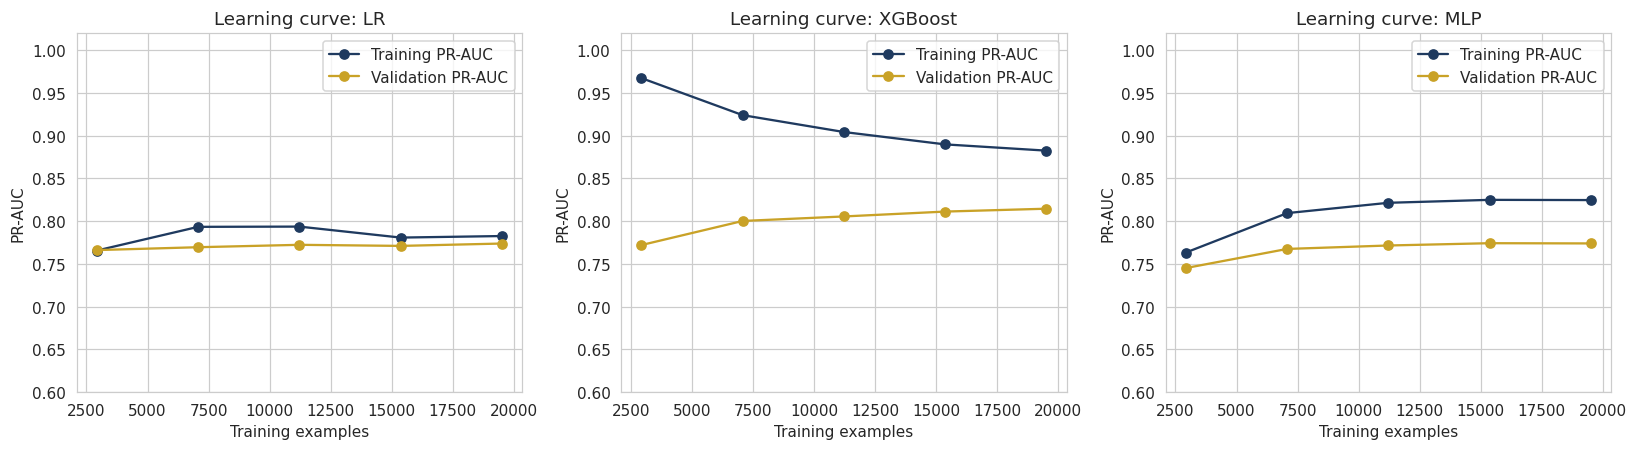

In [49]:
# learning curves: grow the training subset, score PR-AUC on that subset against the validation set
rng = np.random.RandomState(SEED)
fracs = np.linspace(0.15, 1.0, 5)
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for ax, (name, params, builder) in zip(axes, [("LR", lr_best, lr_pipe), ("XGBoost", xgb_best, xgb_pipe), ("MLP", mlp_best, mlp_pipe)]):
    sizes, tr_scores, val_scores = [], [], []
    for frac in fracs:
        n = int(len(Xtr) * frac)
        idx = rng.permutation(len(Xtr))[:n]
        Xs, ys = Xtr.iloc[idx], ytr.iloc[idx]
        m = builder(**params).fit(Xs, ys)
        sizes.append(n)
        tr_scores.append(metrics.average_precision_score(ys, m.predict_proba(Xs)[:, 1]))
        val_scores.append(metrics.average_precision_score(yval, m.predict_proba(Xval)[:, 1]))
    ax.plot(sizes, tr_scores, "o-", color=NAVY, label="Training PR-AUC")
    ax.plot(sizes, val_scores, "o-", color=GOLD, label="Validation PR-AUC")
    ax.set_title(f"Learning curve: {name}")
    ax.set_xlabel("Training examples")
    ax.set_ylabel("PR-AUC")
    ax.set_ylim(0.6, 1.02)
    ax.legend()
plt.tight_layout()
plt.show()

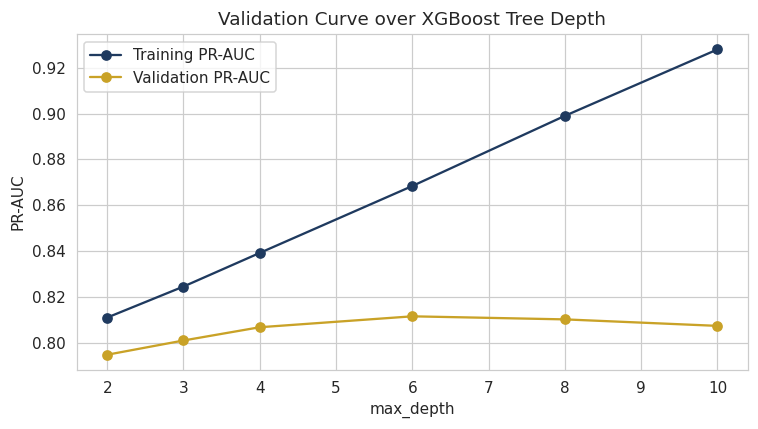

In [50]:
# validation curve over XGBoost tree depth, the parameter that controls how hard it can fit the training rows
depths = [2, 3, 4, 6, 8, 10]
vc_tr, vc_val = [], []
for d in depths:
    p = dict(xgb_best); p["max_depth"] = d
    m = xgb_pipe(**p).fit(Xtr, ytr)
    vc_tr.append(metrics.average_precision_score(ytr, m.predict_proba(Xtr)[:, 1]))
    vc_val.append(metrics.average_precision_score(yval, m.predict_proba(Xval)[:, 1]))
plt.figure(figsize=(7, 4))
plt.plot(depths, vc_tr, "o-", color=NAVY, label="Training PR-AUC")
plt.plot(depths, vc_val, "o-", color=GOLD, label="Validation PR-AUC")
plt.xlabel("max_depth")
plt.ylabel("PR-AUC")
plt.title("Validation Curve over XGBoost Tree Depth")
plt.legend()
plt.tight_layout()
plt.show()

- The learning curves say the same thing for all three. The validation line climbs quickly over the first few
thousand rows and then flattens, so none of them is starved of data in the ordinary sense.
- The gap between the training and validation lines is what separates them. The logistic regression's two lines sit
almost on top of each other, the signature of a low variance model underfitting if anything. XGBoost shows a clear
persistent gap, which is what a 400-tree, depth-7 ensemble is expected to do. That is not a problem in itself since
its validation score is still highest, but it means the capacity is going into fitting training rows.
- The validation curve over depth is the cleaner picture. Training PR-AUC keeps climbing while validation peaks and
flattens, which is textbook overfitting past the peak, and the tuned depth of 7 sits at that peak.
- The MLP's curve moves most between sizes, which fits everything else: it is the model most sensitive to how much
data it gets.
- Nothing suggests XGBoost's advantage is an overfitting artifact, since it shows on held-out rows and on every fold.

In [51]:
# training and prediction cost for each model, since a small accuracy gain has to be weighed against it
timing_rows = []
for name, params, builder in [("LR", lr_best, lr_pipe), ("XGBoost", xgb_best, xgb_pipe), ("MLP", mlp_best, mlp_pipe)]:
    m = builder(**params)
    t0 = time.time(); m.fit(Xtr, ytr); fit_time = time.time() - t0
    t0 = time.time(); _ = m.predict(Xte); pred_time = time.time() - t0
    timing_rows.append({"model": name, "fit seconds": round(fit_time, 2), "predict seconds": round(pred_time, 4)})
print(f"Fit on {len(Xtr):,} training rows, predict on {len(Xte):,} test rows\n")
print(pd.DataFrame(timing_rows).set_index("model").to_string())

Fit on 19,521 training rows, predict on 6,508 test rows

         fit seconds  predict seconds
model                                
LR              2.59           0.0057
XGBoost         3.30           0.0442
MLP             4.88           0.0077


In [52]:
# fixed seed everywhere and the library versions, so this run can be reproduced
import sklearn, imblearn, scipy, xgboost
print("random seed:", SEED)
for name, mod in [("numpy", np), ("pandas", pd), ("scikit-learn", sklearn),
                  ("imbalanced-learn", imblearn), ("xgboost", xgboost), ("scipy", scipy)]:
    print(f"{name:18s} {mod.__version__}")

random seed: 42
numpy              2.4.4
pandas             3.0.2
scikit-learn       1.8.0
imbalanced-learn   0.14.2
xgboost            3.3.0
scipy              1.17.1


- XGBoost fits in about 3.5 seconds against 2.8 for the logistic regression and 5.3 for the MLP, and all three
predict on 6,508 rows in well under a tenth of a second. Compute is not a reason to prefer the simpler model.
- The real cost of XGBoost is interpretability, which is the trade that matters for a lending use case. The logistic
regression gives one signed coefficient per feature, so I can say exactly how much each moved the decision. XGBoost
has 400 trees and no single one carries the answer, so explaining it means gain importance or a surrogate tree, both
of which approximate the model instead of describing it.

## Strengths, limitations, biases, and impact

Strengths

- Every comparison is backed by a test with an interval, not by one number being larger than another, and
where the tests disagreed I said so instead of picking the one I liked.
- The cross-validation is properly paired. All three models saw the same five folds, which is what makes a paired
t-test valid and is the difference between some power and almost none.
- Leakage is hard to cause by accident instead of remembered. The scaler and SMOTE live inside the pipeline so they
refit inside every fold, and each model builds its own scaler.
- The fairness work goes past reporting a gap: I measured it, put an interval on it, tested whether models differ,
tried three fixes, and reported what each cost.
- The hypotheses were stated with their reasoning before the results, so they could be refuted, and one was.

Limitations

- The nativity comparison is underpowered and I could not fix it. With 99 foreign-born high earners, the interval is
wider than any difference worth detecting.
- Grid search on a single validation split instead of nested cross-validation. The final numbers are not
contaminated, but the chosen parameters could be slightly overfit to those 6,508 rows.
- The models are compared at the default 0.5 threshold, where they sit at different recall levels, so the raw group
gap comparison is partly about operating points.
- No calibration analysis. A probability that ranks well is not the same as one that is well calibrated, and a lender
needs the latter.
- SMOTE interpolates between real rows, which is questionable on one-hot columns, where a value between two
categories is not a real category.

Biases

- The data is a 1994 census extract, so any model trained on it inherits the occupational segregation, education
access, and wage gaps of that period.
- The label is itself a bias. \$50K was meaningful in 1994 and is not now, and using recorded income as a proxy for
creditworthiness bakes in whatever inequity produced that distribution.
- The sampling is uneven where the audit cares most: foreign-born people are 9 percent of the data and women are 33
percent, so both contribute far less to what every model learns.
- The models do perform differently across subgroups, and I measured it instead of assuming it. Recall on female
high earners is 11 to 15 points below male for all three, and that is significant.
- Missingness is not random. Workclass and occupation go missing together, so the Unknown bucket is a feature with
meaning attached.

Broader societal impact

- The people affected are applicants who get screened out. A false negative is a qualified person not offered
something they would have qualified for, and the audit shows those land more often on women.
- The obvious misuse is treating a prediction of low income as a reason for an adverse decision. The model has no
causal content, so that would dress up a correlation as a judgment about a person.
- A second misuse is the fairness fix itself. Group-specific thresholds close the gap by using nativity or sex at
prediction time, which is very likely illegal under fair lending rules however good the intent.
- The deeper problem is that a model can be fair on one metric and unfair on another at once. Every model here looks
more accurate on women and misses far more of their high earners, and a report leading with group accuracy would have
concluded the opposite of what is happening.

Takeaway lessons

- A statistical test can be structurally incapable of returning the answer you want. Wilcoxon came back at 0.0625 on
every clean result because that is its floor at five folds.
- Shared mutable objects silently corrupt results. All three pipelines pointed at one scaler, and since scikit-learn
pipelines do not copy their steps, refitting one model later changed the preprocessing of models already scored.
XGBoost's test PR-AUC read 0.744 instead of 0.805 and nothing raised an error.
- Confidence intervals beat p-values when the answer is that you cannot tell. The nativity result is not that the
models are equal, it is that 99 people cannot distinguish them.
- The most accurate model is not automatically the fairest, and here it was the least fair on the raw numbers.
Building the audit into the comparison is what made that visible.
- Group accuracy and group recall can point in opposite directions on the same model, and the reassuring one is
usually the wrong one to read.

## Conclusion

- The project asked whether earning over \$50K can be predicted from 1994 census demographics, and which of three
models does it best and most fairly, framed as a lender that flags likely high earners.
- The research questions were which feature drives the prediction more, education or hours worked; which model has
the smallest US-born versus foreign-born recall gap; and which model classifies best on held-out PR-AUC and F1.
- H1 is supported. Education is worth two and a half to three times as much as hours on permutation importance for
every model, with intervals on the difference that exclude zero, and it is the fourth independent method in this
project to reach that conclusion.
- H3 is supported. XGBoost reaches 0.805 PR-AUC and 0.708 F1 against 0.774 and 0.684 for the tuned baseline, winning
on all five folds and in 1000 of 1000 bootstrap resamples, with the t-test, McNemar, and the bootstrap all agreeing.
The part I would not claim is the MLP beating the baseline.
- H2 is refuted. XGBoost has the largest nativity gap, not the smallest, and no difference between models is
distinguishable, because 99 foreign-born high earners cannot resolve a 0.03 difference. What is measurable is that
all three models miss female high earners 11 to 15 points more often, and that is significant for every model.
- The main finding is the one I did not expect: the most accurate model was not the fairest, and the two questions
had to be answered separately. Group-balanced oversampling recovers most of the fairness gap at almost no cost to F1,
and that is the configuration I would deploy.

Future work

- More foreign-born rows, or a recent census extract, so the nativity comparison has the sample size to settle. The
single change that would do the most.
- Compare the models at a matched recall instead of at 0.5, so the gaps are not confounded with operating points.
- Add calibration curves and Brier scores, since a lender needs probabilities that mean what they say.
- Replace grid search on one validation split with nested cross-validation.
- Try fairness-aware training that constrains the gap while the model is fitting, compared against the oversampling I used.

## Reproducibility and references

Reproducibility

- One fixed seed, 42, on the split, the cross-validation folds, SMOTE, and all three models, and a single load path
from the SQLite database, so the notebook reruns to the same numbers.
- The notebook runs top to bottom on a clean environment with no manual steps. It expects adult.csv in the working
directory and writes adult.db itself.
- The code is separated so that preprocessing, training, and evaluation are in distinct blocks, and the pipeline
factories mean every model is built the same way in every place it appears.
- Library versions are printed above, and requirements.txt in the repository pins them.

References

- Data: Becker, B. and Kohavi, R. (1996). Adult. UCI Machine Learning Repository. https://archive.ics.uci.edu/dataset/2/adult
- Kaggle mirror of the same extract, which is where I pulled the CSV from: https://www.kaggle.com/datasets/uciml/adult-census-income
- scikit-learn: Pedregosa et al. (2011). Scikit-learn: Machine Learning in Python. JMLR 12, 2825-2830. https://scikit-learn.org
- imbalanced-learn and SMOTE: Lemaitre, G., Nogueira, F., Aridas, C. (2017). JMLR 18(17), 1-5. https://imbalanced-learn.org
- SMOTE original paper: Chawla, N., Bowyer, K., Hall, L., Kegelmeyer, W. (2002). SMOTE: Synthetic Minority Over-sampling Technique. JAIR 16, 321-357.
- XGBoost: Chen, T. and Guestrin, C. (2016). XGBoost: A Scalable Tree Boosting System. KDD '16. https://xgboost.readthedocs.io
- Permutation importance: Breiman, L. (2001). Random Forests. Machine Learning 45, 5-32, and the scikit-learn implementation notes at https://scikit-learn.org/stable/modules/permutation_importance.html
- McNemar's test for comparing classifiers: Dietterich, T. (1998). Approximate Statistical Tests for Comparing Supervised Classification Learning Algorithms. Neural Computation 10(7), 1895-1923.
- Bootstrap confidence intervals: Efron, B. and Tibshirani, R. (1993). An Introduction to the Bootstrap.
- scipy.stats for the t-test, Wilcoxon signed-rank test, and exact binomial test: https://docs.scipy.org/doc/scipy/reference/stats.html
- My own earlier milestones in this project, which this report carries forward: the database setup and initial data look, the EDA and feature engineering milestone, and the baseline model milestone, all in https://github.com/ErikHerb/MSDS640-coursework

## How I used an LLM for this assignment

- I used an LLM to help debug my code and troubleshoot errors, including finding a bug where all three of my
pipelines were sharing one scaler object, which was quietly changing my XGBoost results.
- It helped me format the output of my code so the tables printed the way I wanted them to.
- It helped me build some of the plots in this notebook.
- I used it to think through which statistical test fits which comparison, in particular why McNemar's test is the right
one for two classifiers on a shared test set and why the Wilcoxon test bottoms out at 0.0625 with five folds.
- I also used it to check my work against the assignment instructions to make sure I was not missing a required
section.
- I wrote and edited the analysis myself and confirmed every number by running the notebook top to bottom.